# MARI Water Breakthrough Prediction — POC
## Habib Rahi Limestone (HRL) Gas Reservoir

**Client:** Mari Energies  
**Field:** Mari Gas Field, Daharki, Sindh, Pakistan  
**Formation:** Habib Rahi Limestone (Eocene shallow carbonate), ~700 m TVD  
**Drive:** Natural depletion (no injection, no pressure support)  
**GWC:** 684 m TVD SS (field-wide)

### Objective
Predict P10/P50/P90 time-to-water-breakthrough for 4 dry horizontal wells:
- **M-123H**, **M-124H**, **M-125H**, **M-126H**

Using M-122H (broke through at month 12) as validation anchor.

### Event Definition
- **Primary:** Water-Gas Ratio (WGR) > 5 bbl/MMcf, sustained >= 3 consecutive months
- **Refinement:** Chloride concentration to distinguish formation water from condensation

### Model Ladder
1. Kaplan-Meier (field-wide & stratified)
2. Cox Proportional Hazards (interpretable baseline)
3. Weibull AFT (parametric, direct P10/P50/P90)
4. Random Survival Forest (non-linearity benchmark)
5. Physics-constrained Cox/AFT (sign constraints)

### Critical Rules
1. Always include 4 censored dry wells in the fit
2. Physics sign checks: higher Sw, closer-to-GWC, higher perm, higher drawdown -> shorter time
3. Report P10/P50/P90, not point estimates
4. Log every imputation decision
5. M-51 month-0 water: flag, exclude, document
6. Model must beat field-wide KM median baseline

---
## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from datetime import datetime

# Survival analysis
from lifelines import KaplanMeierFitter, CoxPHFitter, WeibullAFTFitter
from lifelines import LogNormalAFTFitter, LogLogisticAFTFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
from lifelines.utils import concordance_index

# Random Survival Forest
try:
    from sksurv.ensemble import RandomSurvivalForest
    from sksurv.util import Surv
    HAS_SKSURV = True
except ImportError:
    HAS_SKSURV = False
    print('scikit-survival not installed. RSF will be skipped.')

import pickle

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

DATA_DIR = Path('new_data')
FIGURES_DIR = Path('figures_mari')
FIGURES_DIR.mkdir(exist_ok=True)

# Constants
GWC_TVD = 684  # m TVD SS, field-wide
WGR_THRESHOLD = 5  # bbl/MMcf
MIN_CONSECUTIVE_MONTHS = 3

print('Setup complete.')

Setup complete.


---
## 2. Data Loading

### 2.1 Pressure

In [2]:
# --- Production data (Sheet: PRESSURES -> actually contains production volumes) ---
prod_raw = pd.read_excel(
    DATA_DIR / 'STIXOR Sharing Data.xlsx',
    sheet_name='Pressures',
    header=1  # Header row is row 3 (0-indexed: 2)
)

# Standardise column names
prod_raw.columns = prod_raw.columns.str.strip()
print('Production sheet columns:', prod_raw.columns.tolist())
print(f'Shape: {prod_raw.shape}')
prod_raw.head(10)

Production sheet columns: ['Unnamed: 0', 'Date', 'Wells', 'Wellhead Flowing Pressure (WHFP)psig', 'Line Pressure psig']
Shape: (5354, 5)


,Unnamed: 0,Date,Wells,Wellhead Flowing Pressure (WHFP)psig,Line Pressure psig
0,NaN,1990-06-01,M-11-HRL,793.1,NaN
1,NaN,1990-08-01,M-11-HRL,NaN,NaN
2,NaN,1990-09-01,M-11-HRL,829.3,NaN
3,NaN,1990-10-01,M-11-HRL,NaN,NaN
4,NaN,1995-01-01,M-11-HRL,818.5,NaN
5,NaN,1995-02-01,M-11-HRL,810.4,NaN
6,NaN,1995-04-01,M-11-HRL,808.9,NaN
7,NaN,1995-05-01,M-11-HRL,778.2,NaN
8,NaN,1995-06-01,M-11-HRL,NaN,NaN
9,NaN,1995-07-01,M-11-HRL,NaN,NaN


In [3]:
prod = prod_raw.iloc[:,1:4]


In [4]:
prod.rename(columns={
    'Date': 'date',
    'Wells': 'well',
    'Wellhead Flowing Pressure (WHFP)psig': 'pressure'
}, inplace=True)

In [5]:
prod

,date,well,pressure
0,1990-06-01,M-11-HRL,793.1
1,1990-08-01,M-11-HRL,NaN
2,1990-09-01,M-11-HRL,829.3
3,1990-10-01,M-11-HRL,NaN
4,1995-01-01,M-11-HRL,818.5
...,...,...,...
5349,2025-02-01,M-E-2-HRL,235.5
5350,2025-03-01,M-E-2-HRL,226.5
5351,2025-04-01,M-E-2-HRL,234.4
5352,2025-05-01,M-E-2-HRL,220.9


In [6]:
# Parse dates
prod['date'] = pd.to_datetime(prod['date'], errors='coerce')
prod = prod.dropna(subset=['date', 'well'])

# Standardise well names: strip whitespace
prod['well'] = prod['well'].str.strip()

print(f'Production data: {len(prod)} rows, {prod["well"].nunique()} wells')
print(f'Date range: {prod["date"].min()} to {prod["date"].max()}')
print(f'Wells: {sorted(prod["well"].unique())}')
prod.describe()

Production data: 5354 rows, 22 wells
Date range: 1990-06-01 00:00:00 to 2025-06-01 00:00:00
Wells: ['M-11-HRL', 'M-122H-HRL', 'M-123H-HRL', 'M-124H-HRL', 'M-125H-HRL', 'M-126H-HRL', 'M-13-HRL', 'M-22-HRL', 'M-41-HRL', 'M-50-HRL', 'M-51-HRL', 'M-56-HRL', 'M-57-HRL', 'M-58-HRL', 'M-61-HRL', 'M-63-HRL', 'M-65-HRL', 'M-67-HRL', 'M-75-HRL', 'M-81-HRL', 'M-82-HRL', 'M-E-2-HRL']


,date,pressure
count,5354,5112.000000
mean,2012-04-11 06:22:43.615988224,526.144190
min,1990-06-01 00:00:00,51.300000
25%,2006-01-01 00:00:00,395.075000
50%,2012-08-01 00:00:00,545.900000
75%,2019-03-01 00:00:00,650.700000
max,2025-06-01 00:00:00,1026.200000
std,NaN,171.331957


### 2.2 Production Data

In [7]:
# --- Pressure / Rates sheet ---
rates_raw = pd.read_excel(
    DATA_DIR / 'STIXOR Sharing Data.xlsx',
    sheet_name='Rates',
    header=1
)
rates_raw.columns = rates_raw.columns.str.strip()
print('Rates sheet columns:', rates_raw.columns.tolist())

Rates sheet columns: ['Unnamed: 0', 'Date', 'Wells', 'CHOKE 1/64"', 'DAYS on production', 'Monthly Gas Produced MMcf (volume)', 'Monthly Water Produced bbl (volume)', 'Unnamed: 7', 'Notes', 'Unnamed: 9']


In [8]:
rates_raw

,Unnamed: 0,Date,Wells,"CHOKE 1/64""",DAYS on production,Monthly Gas Produced MMcf (volume),Monthly Water Produced bbl (volume),Unnamed: 7,Notes,Unnamed: 9
0,NaN,1978-03-01,M-11-HRL,NaN,NaN,27.372,0.00,NaN,1,The Gas Produced and Water Produced are the vo...
1,NaN,1978-04-01,M-11-HRL,NaN,NaN,321.709,47.70,NaN,2,The rates can be calculated suing the volume a...
2,NaN,1978-05-01,M-11-HRL,NaN,NaN,299.598,82.46,NaN,3,The fluid ratios can be estimated using the vo...
3,NaN,1978-06-01,M-11-HRL,NaN,NaN,235.951,179.10,NaN,4,The WHFP (well head flowing pressure) and line...
4,NaN,1978-07-01,M-11-HRL,NaN,NaN,240.720,145.08,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
6647,NaN,2025-02-01,M-E-2-HRL,128.0,24.0,122.895,NaN,NaN,NaN,NaN
6648,NaN,2025-03-01,M-E-2-HRL,128.0,27.0,163.161,NaN,NaN,NaN,NaN
6649,NaN,2025-04-01,M-E-2-HRL,128.0,30.0,141.786,NaN,NaN,NaN,NaN
6650,NaN,2025-05-01,M-E-2-HRL,128.0,31.0,143.860,NaN,NaN,NaN,NaN


In [9]:
rates = rates_raw.iloc[:,1:7]
rates

,Date,Wells,"CHOKE 1/64""",DAYS on production,Monthly Gas Produced MMcf (volume),Monthly Water Produced bbl (volume)
0,1978-03-01,M-11-HRL,NaN,NaN,27.372,0.00
1,1978-04-01,M-11-HRL,NaN,NaN,321.709,47.70
2,1978-05-01,M-11-HRL,NaN,NaN,299.598,82.46
3,1978-06-01,M-11-HRL,NaN,NaN,235.951,179.10
4,1978-07-01,M-11-HRL,NaN,NaN,240.720,145.08
...,...,...,...,...,...,...
6647,2025-02-01,M-E-2-HRL,128.0,24.0,122.895,NaN
6648,2025-03-01,M-E-2-HRL,128.0,27.0,163.161,NaN
6649,2025-04-01,M-E-2-HRL,128.0,30.0,141.786,NaN
6650,2025-05-01,M-E-2-HRL,128.0,31.0,143.860,NaN


In [10]:

rates.rename(columns={
    'Date': 'date',
    'Wells': 'well',
    'CHOKE 1/64"': 'choke_size',
    'DAYS on production': 'prod_days',
    'Monthly Gas Produced MMcf (volume)': 'gas_produced',
    'Monthly Water Produced bbl (volume)': 'water_produced'


}, inplace=True)

rates['date'] = pd.to_datetime(rates['date'], errors='coerce')
rates = rates.dropna(subset=['date', 'well'])
rates['well'] = rates['well'].str.strip()

print(f'Rates data: {len(rates)} rows, {rates["well"].nunique()} wells')
print(f'Date range: {rates["date"].min()} to {rates["date"].max()}')
rates.head()

Rates data: 6652 rows, 22 wells
Date range: 1978-03-01 00:00:00 to 2025-06-01 00:00:00


,date,well,choke_size,prod_days,gas_produced,water_produced
0,1978-03-01,M-11-HRL,NaN,NaN,27.372,0.00
1,1978-04-01,M-11-HRL,NaN,NaN,321.709,47.70
2,1978-05-01,M-11-HRL,NaN,NaN,299.598,82.46
3,1978-06-01,M-11-HRL,NaN,NaN,235.951,179.10
4,1978-07-01,M-11-HRL,NaN,NaN,240.720,145.08


In [11]:
rates['choke_size'].value_counts()

choke_size
48.0     592
64.0     537
32.0     379
96.0     308
128.0    173
60.0      33
24.0      19
40.0      16
112.0      9
28.0       7
72.0       7
12.0       3
36.0       2
56.0       2
54.0       1
110.0      1
66.0       1
20.0       1
Name: count, dtype: int64

In [12]:
rates['prod_days'].value_counts()

prod_days
31.00    1103
30.00     644
28.00     135
29.00      73
27.00      34
26.00      20
24.00      19
25.00      13
22.00       7
21.00       7
23.00       6
16.00       5
13.00       3
20.00       3
15.00       3
17.00       3
18.00       2
14.00       2
11.00       2
19.00       2
6.00        1
1.40        1
1.56        1
10.00       1
3.00        1
9.00        1
Name: count, dtype: int64

In [13]:
rates.describe()

,date,choke_size,prod_days,gas_produced,water_produced
count,6652,2091.000000,2092.000000,6622.000000,4683.000000
mean,2008-02-25 05:26:00.793746176,63.069345,29.874742,117.512217,636.161544
min,1978-03-01 00:00:00,12.000000,1.400000,0.000000,0.000000
25%,1999-11-01 00:00:00,48.000000,30.000000,69.134000,78.107500
50%,2009-04-01 00:00:00,60.000000,31.000000,96.842500,314.500000
75%,2017-09-01 00:00:00,64.000000,31.000000,154.529500,921.535500
max,2025-06-01 00:00:00,128.000000,31.000000,475.617000,6382.976000
std,NaN,28.065209,2.540252,73.870030,862.296954


In [14]:
rates.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6652 entries, 0 to 6651
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            6652 non-null   datetime64[ns]
 1   well            6652 non-null   object        
 2   choke_size      2091 non-null   float64       
 3   prod_days       2092 non-null   float64       
 4   gas_produced    6622 non-null   float64       
 5   water_produced  4683 non-null   float64       
dtypes: datetime64[ns](1), float64(4), object(1)
memory usage: 311.9+ KB


### 2.3 Subsurface Static Properties

In [15]:
# --- Subsurface data ---
sub_raw = pd.read_excel(
    DATA_DIR / 'Subsurface data- Stixors Technologies.xlsx',
    header=2
)
sub_raw.columns = sub_raw.columns.str.strip()
print('Subsurface columns:', sub_raw.columns.tolist())

# Rename columns
col_map_sub = {}
for c in sub_raw.columns:
    cl = c.lower()
    if 'well' in cl:
        col_map_sub[c] = 'well'
    elif 'poro' in cl:
        col_map_sub[c] = 'porosity'
    elif 'perm' in cl:
        col_map_sub[c] = 'permeability_md'
    elif 'skin' in cl:
        col_map_sub[c] = 'skin'
    elif 'water' in cl and 'sat' in cl:
        col_map_sub[c] = 'sw'
    elif 'net' in cl and 'pay' in cl:
        col_map_sub[c] = 'net_pay_m'
    elif 'chlor' in cl:
        col_map_sub[c] = 'chlorides_ppm'
    elif 'top' in cl and 'perf' in cl:
        col_map_sub[c] = 'top_perf_md'
    elif 'bottom' in cl and 'perf' in cl:
        col_map_sub[c] = 'bottom_perf_md'

sub = sub_raw.rename(columns=col_map_sub).copy()
sub = sub.dropna(subset=['well'])
sub['well'] = sub['well'].str.strip()

for c in ['porosity', 'permeability_md', 'skin', 'sw', 'net_pay_m',
          'chlorides_ppm', 'top_perf_md', 'bottom_perf_md']:
    if c in sub.columns:
        sub[c] = pd.to_numeric(sub[c], errors='coerce')

# Derived: perforation midpoint (MD — used as proxy until TVD available)
sub['perf_midpoint_md'] = (sub['top_perf_md'] + sub['bottom_perf_md']) / 2

print(f'Subsurface data: {len(sub)} wells')
sub

Subsurface columns: ['Unnamed: 0', 'Wells', 'Porosity', 'Permeability (mD) - PTA', 'Skin', 'Water saturation', 'Net pay (m) \nMeasured Depth', 'Chlorides (ppm)', 'Top Perf (m)', 'Bottom Perf (m)', 'Unnamed: 10', 'Unnamed: 11']
Subsurface data: 22 wells


,Unnamed: 0,well,porosity,permeability_md,skin,sw,net_pay_m,chlorides_ppm,top_perf_md,bottom_perf_md,Unnamed: 10,Unnamed: 11,perf_midpoint_md
0,NaN,M-11-HRL,0.20,7.4,-0.1,0.45,10.500000,17000,695.000000,705.500000,NaN,Notes:,700.250000
1,NaN,M-122H-HRL,0.22,34.0,NaN,0.46,530.000000,13000,1020.000000,1550.000000,NaN,NaN,1285.000000
2,NaN,M-123H-HRL,0.24,22.5,NaN,0.30,802.000000,1215,1044.000000,1846.000000,NaN,NaN,1445.000000
3,NaN,M-124H-HRL,0.22,34.0,NaN,0.46,475.000000,10000,918.000000,1393.000000,NaN,NaN,1155.500000
4,NaN,M-125H-HRL,0.24,22.5,NaN,0.30,758.000000,2500,951.000000,1709.000000,NaN,NaN,1330.000000
5,NaN,M-126H-HRL,0.22,34.0,NaN,0.46,719.000000,13000,993.000000,1712.000000,NaN,NaN,1352.500000
6,NaN,M-13-HRL,0.18,9.5,-2.8,0.31,10.200000,15000,691.600000,701.800000,NaN,NaN,696.700000
7,NaN,M-22-HRL,0.19,5.9,5.3,0.42,11.650000,14000,708.750000,720.400000,NaN,NaN,714.575000
8,NaN,M-41-HRL,0.17,37.1,-0.1,0.13,10.700000,13000,697.500000,708.200000,NaN,NaN,702.850000
9,NaN,M-50-HRL,0.19,17.8,1.4,0.43,10.700000,15000,697.500000,708.200000,NaN,NaN,702.850000


In [16]:
sub = sub[['well', 'porosity', 'permeability_md', 'skin', 'sw',
       'net_pay_m', 'chlorides_ppm', 'top_perf_md', 'bottom_perf_md', 'perf_midpoint_md']]

### 2.4 Annual BHP & Gas Gravity (Pressure data file)

In [17]:
gas_gravity_df = pd.read_csv('/Users/saifullahkatpar/Desktop/water-breakthrough-prediction/new_data/gas_gravity.csv')
gas_gravity_df

,well,gas_gravity
0,M-11-HRL,0.70
1,M-122H-HRL,0.77
2,M-123H-HRL,0.75
3,M-124H-HRL,0.76
4,M-125H-HRL,0.75
5,M-126H-HRL,0.78
6,M-13-HRL,0.69
7,M-22-HRL,0.77
8,M-41-HRL,0.69
9,M-50-HRL,0.76


In [18]:
bhp = pd.read_csv('/Users/saifullahkatpar/Desktop/water-breakthrough-prediction/new_data/BHP.csv')
bhp

,well,date,bhp
0,11,1-Nov-88,1053.0
1,11,19-May-90,1067.0
2,11,26-Nov-91,1048.0
3,11,11-Feb-92,1034.0
4,11,23-Aug-93,1022.0
...,...,...,...
310,122H,01-Jul-23,646.0
311,123H,01-Jul-24,601.0
312,124H,01-Jul-24,655.0
313,125H,01-May-25,560.0


---
## 3. Data Joining & Panel Construction

**CRITICAL FIX:** the original merge joined production onto pressures (`prod.merge(rates)`), which truncated the panel to the row count of the pressure sheet (5,354). Because pressures only start Jun 1990, this **erased decades of pre-1990 production for the 6 oldest wells** (M-11, M-13, M-22, M-41, M-50, M-51). Time-to-event for those wells was systematically wrong.

The fix: production volumes drive the panel; pressures and statics are left-joined on top. Expected row count: ~6,652 (matches the Rates sheet).

In [19]:
# --- Production-driven panel (FIXED) ---
prod['date']  = prod['date'].dt.to_period('M').dt.to_timestamp()
rates['date'] = rates['date'].dt.to_period('M').dt.to_timestamp()

# `rates` (from Rates sheet) is the production volumes - full history 1978-2025.
# `prod`  (from Pressures sheet, despite its name) is just the WHFP series.
# Left-merge prod onto rates so production drives row count.
panel = rates.merge(prod, on=['well','date'], how='left')

# Standardise column names that downstream code expects
panel = panel.rename(columns={
    'gas_produced'  : 'gas_mmcf',
    'water_produced': 'water_bbl',
    'prod_days'     : 'days_on_prod',
    'choke_size'    : 'choke_64ths',
    'pressure'      : 'whfp_psig',
})
# Line pressure column may or may not be present depending on what was loaded;
# create empty if missing
if 'line_pressure_psig' not in panel.columns:
    panel['line_pressure_psig'] = np.nan

print(f'Panel rows: {len(panel)}   (expected ~6,652)')
print(f'Date range: {panel["date"].min().date()} -> {panel["date"].max().date()}')
print(f'\nPer-well month counts (M-11 should be ~567, NOT 326):')
print(panel.groupby('well').size().sort_values(ascending=False).head(10).to_string())

Panel rows: 6652   (expected ~6,652)
Date range: 1978-03-01 -> 2025-06-01

Per-well month counts (M-11 should be ~567, NOT 326):
well
M-11-HRL    567
M-13-HRL    562
M-22-HRL    524
M-41-HRL    470
M-50-HRL    470
M-51-HRL    464
M-58-HRL    383
M-57-HRL    383
M-56-HRL    383
M-61-HRL    378


In [20]:
# --- Reconcile well naming and merge static subsurface properties ---
prod_wells = set(panel['well'].unique())
sub_wells  = set(sub['well'].unique())

direct = prod_wells & sub_wells
print(f'Direct name matches: {len(direct)} / {len(prod_wells)}')

if len(direct) < len(prod_wells):
    # Build a number-based map
    import re
    def well_num(name):
        m = re.search(r'(\d+H?)', str(name))
        return m.group(1) if m else str(name)
    sub_by_num = {well_num(w): w for w in sub_wells}
    well_map = {pw: sub_by_num.get(well_num(pw), None) for pw in prod_wells}
    unmatched = [k for k,v in well_map.items() if v is None]
    if unmatched:
        print(f'WARNING: unmatched wells: {unmatched}')
    panel['well_sub'] = panel['well'].map(well_map)
    panel = panel.merge(sub, left_on='well_sub', right_on='well', how='left',
                        suffixes=('','_sub'))
    panel = panel.drop(columns=[c for c in ['well_sub','well_sub_sub'] if c in panel.columns])
    if 'well_sub' in panel.columns:
        panel = panel.drop(columns=['well_sub'])
else:
    panel = panel.merge(sub, on='well', how='left')

print(f'Panel after static merge: {panel.shape}')
panel.head(3)

Direct name matches: 22 / 22
Panel after static merge: (6652, 17)


,date,well,choke_64ths,days_on_prod,gas_mmcf,water_bbl,whfp_psig,line_pressure_psig,porosity,permeability_md,skin,sw,net_pay_m,chlorides_ppm,top_perf_md,bottom_perf_md,perf_midpoint_md
0,1978-03-01,M-11-HRL,NaN,NaN,27.372,0.00,NaN,NaN,0.2,7.4,-0.1,0.45,10.5,17000,695.0,705.5,700.25
1,1978-04-01,M-11-HRL,NaN,NaN,321.709,47.70,NaN,NaN,0.2,7.4,-0.1,0.45,10.5,17000,695.0,705.5,700.25
2,1978-05-01,M-11-HRL,NaN,NaN,299.598,82.46,NaN,NaN,0.2,7.4,-0.1,0.45,10.5,17000,695.0,705.5,700.25


In [21]:
# --- Interpolate BHP onto monthly panel ---
if len(bhp) > 0 and 'date' in bhp.columns and 'bhp' in bhp.columns:
    bhp['date'] = pd.to_datetime(bhp['date'])
    bhp['well'] = bhp['well'].astype(str).str.strip()
    
    # Reconcile bhp well naming with panel
    bhp_wells = set(bhp['well'].unique())
    if not bhp_wells.intersection(panel['well'].unique()):
        # Try number-based reconciliation
        import re
        def wn(name):
            m = re.search(r'(\d+H?)', str(name)); return m.group(1) if m else str(name)
        bhp_to_panel = {bw: next((pw for pw in panel['well'].unique() if wn(pw)==wn(bw)), bw) for bw in bhp_wells}
        bhp['well'] = bhp['well'].map(bhp_to_panel)
    
    bhp_monthly = []
    for w, wd in bhp.groupby('well'):
        wd = wd.sort_values('date').set_index('date')
        wd = wd[['bhp']].resample('MS').mean().interpolate(method='linear', limit=24)
        wd['well'] = w
        bhp_monthly.append(wd.reset_index())
    bhp_monthly = pd.concat(bhp_monthly, ignore_index=True)
    panel = panel.merge(bhp_monthly, on=['well','date'], how='left')
    print(f'BHP coverage: {panel["bhp"].notna().sum()} / {len(panel)} '
          f'({panel["bhp"].notna().mean()*100:.1f}%)')
else:
    panel['bhp'] = np.nan
    print('No BHP data available')

# Initial reservoir pressure = first BHP reading per well
initial_bhp = panel.dropna(subset=['bhp']).groupby('well')['bhp'].first()
panel['initial_bhp'] = panel['well'].map(initial_bhp)
print(f'\nInitial BHP per well:')
print(initial_bhp.round(1).to_string())

# Gas gravity merge
if 'gas_gravity_df' in dir() and len(gas_gravity_df) > 0:
    gg = gas_gravity_df.copy()
    gg.columns = [c.lower().strip() for c in gg.columns]
    # Rename common variants
    for src in ['well','wells','well_id','name']:
        if src in gg.columns and src != 'well':
            gg = gg.rename(columns={src:'well'})
    for src in ['gas_specific_gravity','gas specific gravity','sg','gas_gravity','gas gravity']:
        if src in gg.columns and src != 'gas_gravity':
            gg = gg.rename(columns={src:'gas_gravity'})
    gg['well'] = gg['well'].astype(str).str.strip()
    # Reconcile names
    import re
    def wn(name):
        m = re.search(r'(\d+H?)', str(name)); return m.group(1) if m else str(name)
    panel_well_by_num = {wn(w): w for w in panel['well'].unique()}
    gg['well'] = gg['well'].map(lambda w: panel_well_by_num.get(wn(w), w))
    panel = panel.merge(gg[['well','gas_gravity']], on='well', how='left')
    print(f'\nGas gravity merged for {panel["gas_gravity"].notna().sum() / len(panel) * 100:.1f}% of rows')
else:
    panel['gas_gravity'] = np.nan

BHP coverage: 4436 / 6652 (66.7%)

Initial BHP per well:
well
M-11-HRL      1053.0
M-122H-HRL     646.0
M-123H-HRL     601.0
M-124H-HRL     655.0
M-125H-HRL     560.0
M-13-HRL      1027.3
M-22-HRL      1087.5
M-41-HRL      1063.0
M-50-HRL      1056.0
M-51-HRL      1104.0
M-56-HRL       985.0
M-57-HRL       987.0
M-58-HRL      1022.0
M-61-HRL      1039.0
M-63-HRL       982.0
M-65-HRL       954.0
M-67-HRL       992.0
M-75-HRL      1051.5
M-81-HRL      1033.0
M-82-HRL      1004.0
M-E-2-HRL      870.0

Gas gravity merged for 100.0% of rows


---
## 4. Feature Engineering

In [22]:
# --- Compute derived features ---

# 4.1 Water-Gas Ratio (WGR) - primary breakthrough metric
panel['wgr'] = panel['water_bbl'] / panel['gas_mmcf'].replace(0, np.nan)
panel['wgr'] = panel['wgr'].fillna(0).clip(lower=0)

# 4.2 Daily gas rate (MMcf/d)
panel['days_in_month'] = panel['days_on_prod'].fillna(panel['date'].dt.days_in_month)
panel['gas_rate_mmcfd']   = panel['gas_mmcf']  / panel['days_in_month'].replace(0, np.nan)
panel['water_rate_bpd']   = panel['water_bbl'] / panel['days_in_month'].replace(0, np.nan)

# 4.3-4.4 Cumulative volumes per well (material balance proxy)
panel = panel.sort_values(['well','date']).reset_index(drop=True)
panel['cum_gas_mmcf']  = panel.groupby('well')['gas_mmcf'].cumsum()
panel['cum_water_bbl'] = panel.groupby('well')['water_bbl'].cumsum()

# 4.5 Months from first production per well
first_prod_date = panel[panel['gas_mmcf'] > 0].groupby('well')['date'].min()
panel['first_prod_date'] = panel['well'].map(first_prod_date)
panel['months_from_start'] = (
    (panel['date'] - panel['first_prod_date']).dt.days / 30.44
).round(1)

# 4.6 WHFP decline rate (FIXED: was using forward-looking diff(-1)*-1 which is wrong sign)
# We want backward-looking decline: pressure_t - pressure_{t-1}
panel['whfp_decline_rate']     = panel.groupby('well')['whfp_psig'].diff()
panel['whfp_decline_rate_3mo'] = panel.groupby('well')['whfp_psig'].diff(periods=3) / 3

# 4.7 Drawdown
panel['drawdown_psi'] = panel['whfp_psig'] - panel['line_pressure_psig']

# 4.8 Well type (FIXED: hard-list approach is unambiguous)
HORIZONTAL_WELLS = {'122H','123H','124H','125H','126H',
                    'M-122H-HRL','M-123H-HRL','M-124H-HRL','M-125H-HRL','M-126H-HRL'}
panel['is_horizontal'] = panel['well'].isin(HORIZONTAL_WELLS).astype(int)

# 4.9 Zone (A for verticals, B for horizontals)
# Based on physics observation: horizontal perfs at ~740m TVD vs reported GWC 684m TVD SS
# suggests horizontals target a deeper sub-zone (Habib Rahi Zn-B in completion sketches)
panel['zone'] = np.where(panel['is_horizontal']==1, 'B', 'A')

# 4.10 Log transforms for skewed features
panel['log_perm']     = np.log(panel['permeability_md'].clip(lower=0.1))
panel['log_gas_rate'] = np.log(panel['gas_rate_mmcfd'].clip(lower=0.001))
panel['log_cum_gas']  = np.log(panel['cum_gas_mmcf'].clip(lower=0.001))

# 4.11 Mobility ratio (Corey-type, k_rw ~ Sw^2)
MU_GAS, MU_WATER = 0.02, 0.5
panel['krw_est']  = panel['sw']**2
panel['krg_est']  = (1 - panel['sw'])**2
panel['mobility_ratio'] = (panel['krw_est']/MU_WATER) / (panel['krg_est']/MU_GAS).replace(0, np.nan)
panel['log_mobility']   = np.log(panel['mobility_ratio'].clip(lower=0.001))

# 4.12 Distance to GWC
# CAVEAT: GWC = 684m TVD SS, but perforation depths are in MD from rotary table.
# For VERTICAL wells (RKB ~60-70m, perfs ~700m MD), TVD ~ MD - RKB elevation,
# so dist_to_gwc using MD has a constant offset that washes out in the model.
# For HORIZONTAL wells, MD is hundreds of metres longer than TVD, making the
# raw MD-based distance meaningless. We override with TVD from completion sketches
# for horizontals (M-122H heel TVD ~740m, all horizontals similar).
HORIZONTAL_TVD_PROXY = 735.0  # metres, from M-122H sketch (heel ~740, toe ~742)

panel['dist_to_gwc_m'] = np.where(
    panel['is_horizontal']==1,
    GWC_TVD - HORIZONTAL_TVD_PROXY,    # constant negative for horizontals
    GWC_TVD - panel['perf_midpoint_md']  # MD-based for verticals (with offset)
)
panel['below_gwc'] = (panel['dist_to_gwc_m'] < 0).astype(int)

print('Feature engineering complete.')
print(f'Panel shape: {panel.shape}')
print(f'\nHorizontal wells (is_horizontal=1): {panel[panel["is_horizontal"]==1]["well"].unique()}')
print(f'Wells with perfs below GWC (verticals only): '
      f'{panel[(panel["below_gwc"]==1) & (panel["is_horizontal"]==0)]["well"].unique()}')

Feature engineering complete.
Panel shape: (6652, 42)

Horizontal wells (is_horizontal=1): ['M-122H-HRL' 'M-123H-HRL' 'M-124H-HRL' 'M-125H-HRL' 'M-126H-HRL']
Wells with perfs below GWC (verticals only): ['M-11-HRL' 'M-13-HRL' 'M-22-HRL' 'M-41-HRL' 'M-50-HRL' 'M-51-HRL'
 'M-56-HRL' 'M-57-HRL' 'M-58-HRL' 'M-61-HRL' 'M-63-HRL' 'M-65-HRL'
 'M-67-HRL' 'M-75-HRL' 'M-81-HRL' 'M-82-HRL' 'M-E-2-HRL']


### 4.1 Imputation Log

All missing-data workarounds documented for traceability. The imputation log will be saved with the model artifacts.

In [23]:
imputation_log = []

# Choke: impute pre-Aug 2015 missing values with per-well median of post-2015
post_2015 = panel[panel['date'] >= '2015-08-01']
choke_medians = post_2015.groupby('well')['choke_64ths'].median()
mask_missing_choke = panel['choke_64ths'].isna()
panel.loc[mask_missing_choke, 'choke_64ths'] = panel.loc[mask_missing_choke, 'well'].map(choke_medians)
imputation_log.append({
    'feature':'choke_64ths',
    'strategy':'Per-well median of post-Aug-2015 values',
    'rows_imputed':int(mask_missing_choke.sum()),
    'rationale':'Pre-2015 choke records unavailable for 17 legacy wells'
})

# Water: missing -> 0
mask_missing_water = panel['water_bbl'].isna()
panel['water_bbl'] = panel['water_bbl'].fillna(0)
panel['wgr'] = panel['water_bbl'] / panel['gas_mmcf'].replace(0, np.nan)
panel['wgr'] = panel['wgr'].fillna(0).clip(lower=0)
imputation_log.append({
    'feature':'water_bbl',
    'strategy':'Fill NaN with 0',
    'rows_imputed':int(mask_missing_water.sum()),
    'rationale':'Missing water records assumed to be zero water production'
})

# WHFP: forward-fill within well (short gaps); pre-1990 remains NaN for the 6 old wells
n_whfp_before = panel['whfp_psig'].isna().sum()
panel['whfp_psig'] = panel.groupby('well')['whfp_psig'].ffill()
n_whfp_after = panel['whfp_psig'].isna().sum()
imputation_log.append({
    'feature':'whfp_psig',
    'strategy':'Forward-fill within well',
    'rows_imputed':int(n_whfp_before - n_whfp_after),
    'rationale':'WHFP starts Jun 1990; pre-1990 NaN for M-11/13/22/41/50/51 (use BHP instead)'
})

# Skin: 0 for the 5 horizontals (no PTA available)
mask_missing_skin = panel['skin'].isna()
panel['skin'] = panel['skin'].fillna(0)
imputation_log.append({
    'feature':'skin',
    'strategy':'Fill NaN with 0',
    'rows_imputed':int(mask_missing_skin.sum()),
    'rationale':'5 horizontal wells lack PTA data; skin=0 is neutral assumption'
})

# Gas gravity: field-mean fallback for any missing wells
if panel['gas_gravity'].isna().any():
    field_mean_gg = panel['gas_gravity'].mean()
    n_gg = panel['gas_gravity'].isna().sum()
    panel['gas_gravity'] = panel['gas_gravity'].fillna(field_mean_gg)
    imputation_log.append({
        'feature':'gas_gravity',
        'strategy':f'Field-mean fallback ({field_mean_gg:.3f})',
        'rows_imputed':int(n_gg),
        'rationale':'Wells without gas gravity get field average'
    })

imp_df = pd.DataFrame(imputation_log)
print('=== IMPUTATION LOG ===')
print(imp_df.to_string(index=False))

=== IMPUTATION LOG ===
    feature                                strategy  rows_imputed                                                                    rationale
choke_64ths Per-well median of post-Aug-2015 values          4561                       Pre-2015 choke records unavailable for 17 legacy wells
  water_bbl                         Fill NaN with 0          1969                    Missing water records assumed to be zero water production
  whfp_psig                Forward-fill within well          1062 WHFP starts Jun 1990; pre-1990 NaN for M-11/13/22/41/50/51 (use BHP instead)
       skin                         Fill NaN with 0            90               5 horizontal wells lack PTA data; skin=0 is neutral assumption


---
## 5. Breakthrough Event Detection & Cohort Definition

Detect water breakthrough using sustained WGR > 5 bbl/MMcf for 3+ consecutive months.

**Critical rule:** events are defined on actual production months only (`gas_mmcf > 0`), and the time-to-event clock starts from the well's true first production date — which, with the corrected panel, now spans 1978–2025 instead of 1990–2025.

In [24]:
def detect_breakthrough_wgr(well_df, threshold=WGR_THRESHOLD,
                            min_consecutive=MIN_CONSECUTIVE_MONTHS):
    """
    Detect water breakthrough for a single well.
    Sustained WGR >= threshold for >= min_consecutive months.
    Returns dict with event time, event flag, and early-life features.
    
    FIX: reset_index after the gas_mmcf>0 filter so consecutive-run lookups
    don't fail on shut-in wells (which previously raised KeyError).
    """
    df = well_df.sort_values('date').copy()
    df = df[df['gas_mmcf'] > 0].reset_index(drop=True)   # FIX: reset_index
    if len(df) == 0:
        return None

    first_prod = df['date'].min()
    df['months_from_start'] = ((df['date'] - first_prod).dt.days / 30.44).round(1)

    # Sustained-run detection
    df['above_thresh'] = (df['wgr'] >= threshold).astype(int)
    df['consec'] = df['above_thresh'].groupby(
        (df['above_thresh'] != df['above_thresh'].shift()).cumsum()
    ).cumcount() + 1

    sustained = df[(df['above_thresh']==1) & (df['consec']>=min_consecutive)]
    if len(sustained) > 0:
        bt_idx = sustained.index[0]
        # Walk backward to start of run
        run_start = bt_idx
        while run_start > 0 and df.loc[run_start-1, 'above_thresh'] == 1:
            run_start -= 1
        bt_month = df.loc[run_start, 'months_from_start']
        bt_date  = df.loc[run_start, 'date']
        event = 1
    else:
        bt_month = df['months_from_start'].max()
        bt_date  = None
        event = 0

    # Early production features (first 6 months of TRUE production)
    early = df[df['months_from_start'] <= 6]

    return {
        'first_prod_date'      : first_prod,
        'breakthrough_date'    : bt_date,
        'time_to_event_months' : max(bt_month, 0.5),
        'event_observed'       : event,
        'production_months'    : df['months_from_start'].max(),
        'early_gas_rate'       : early['gas_rate_mmcfd'].mean()  if len(early) > 0 else np.nan,
        'early_wgr'            : early['wgr'].mean()              if len(early) > 0 else np.nan,
        'early_whfp'           : early['whfp_psig'].mean()        if len(early) > 0 else np.nan,
        'first_month_wgr'      : df.iloc[0]['wgr']                if len(df) > 0 else np.nan,
        'total_gas_mmcf'       : df['gas_mmcf'].sum(),
        'total_water_bbl'      : df['water_bbl'].sum(),
        'final_wgr'            : df['wgr'].iloc[-6:].mean()       if len(df) >= 6 else df['wgr'].mean(),
        'max_wgr'              : df['wgr'].max(),
    }

bt_results = {}
for w in panel['well'].unique():
    r = detect_breakthrough_wgr(panel[panel['well'] == w])
    if r is not None:
        bt_results[w] = r

bt_df = pd.DataFrame(bt_results).T
bt_df.index.name = 'well'
bt_df = bt_df.reset_index()

print(f'Breakthrough detection: {len(bt_df)} wells')
print(f'  WET (event=1): {int(bt_df["event_observed"].sum())}')
print(f'  DRY (censored): {int((bt_df["event_observed"]==0).sum())}')
print()
print(bt_df[['well','time_to_event_months','event_observed',
             'first_month_wgr','early_wgr','max_wgr','production_months']]
      .sort_values('time_to_event_months').to_string(index=False))

Breakthrough detection: 22 wells
  WET (event=1): 14
  DRY (censored): 8

      well time_to_event_months event_observed first_month_wgr early_wgr     max_wgr production_months
M-126H-HRL                  8.0              0             0.0       0.0         0.0               8.0
M-125H-HRL                  9.0              0             0.0       0.0         0.0               9.0
M-122H-HRL                 12.0              1             0.0  0.132922   26.547668              30.0
M-124H-HRL                 18.0              0             0.0       0.0         0.0              18.0
M-123H-HRL                 19.0              0             0.0       0.0         0.0              19.0
  M-67-HRL                 45.0              1             0.0       0.0   46.860408             346.0
  M-82-HRL                 48.0              1        0.047787  0.059425   32.376287             260.0
  M-81-HRL                 57.0              1        0.120735  0.573768   21.509694             251.0

In [31]:
# --- Build survival dataset (one row per well) ---
survival = bt_df.merge(
    sub[['well','porosity','permeability_md','sw','net_pay_m','chlorides_ppm',
         'perf_midpoint_md','skin','top_perf_md','bottom_perf_md']],
    on='well', how='left'
)

# FIX: bt_df comes from .T on a dict-of-dicts, so numeric columns are object dtype.
# Force numeric dtype before any np.log / arithmetic.
numeric_cols = ['time_to_event_months','event_observed','production_months',
                'early_gas_rate','early_wgr','early_whfp','first_month_wgr',
                'total_gas_mmcf','total_water_bbl','final_wgr','max_wgr',
                'porosity','permeability_md','sw','net_pay_m','chlorides_ppm',
                'perf_midpoint_md','skin','top_perf_md','bottom_perf_md']
for c in numeric_cols:
    if c in survival.columns:
        survival[c] = pd.to_numeric(survival[c], errors='coerce')

# Re-derive per-well static features
survival['log_perm'] = np.log(survival['permeability_md'].clip(lower=0.1))

HORIZONTAL_WELLS = {'122H','123H','124H','125H','126H',
                    'M-122H-HRL','M-123H-HRL','M-124H-HRL','M-125H-HRL','M-126H-HRL'}
survival['is_horizontal'] = survival['well'].isin(HORIZONTAL_WELLS).astype(int)
survival['zone']          = np.where(survival['is_horizontal']==1, 'B', 'A')

HORIZONTAL_TVD_PROXY = 735.0
survival['dist_to_gwc_m'] = np.where(
    survival['is_horizontal']==1,
    GWC_TVD - HORIZONTAL_TVD_PROXY,
    GWC_TVD - survival['perf_midpoint_md']
)
survival['below_gwc'] = (survival['dist_to_gwc_m'] < 0).astype(int)

survival['krw_est'] = survival['sw']**2
survival['krg_est'] = (1 - survival['sw'])**2
survival['mobility_ratio'] = ((survival['krw_est']/MU_WATER)
                              / (survival['krg_est']/MU_GAS).replace(0, np.nan))
survival['log_mobility'] = np.log(survival['mobility_ratio'].clip(lower=0.001))
survival['log_gas_rate'] = np.log(survival['early_gas_rate'].clip(lower=0.001))

print(f'\nSurvival dataset: {len(survival)} wells x {len(survival.columns)} features')
print(f'Dtypes check (early_gas_rate should be float64): {survival["early_gas_rate"].dtype}')


Survival dataset: 22 wells x 33 features
Dtypes check (early_gas_rate should be float64): float64


In [32]:
# --- TRAIN / VALIDATION / FORECAST SPLIT (verified against production behaviour) ---
#
# DECISION RATIONALE:
#
#   FORECAST TARGETS (4 wells): M-123H, M-124H, M-125H, M-126H
#     - The four currently-dry horizontals Mari needs P10/P50/P90 for.
#
#   VALIDATION ANCHOR: M-122H
#     - Only horizontal with a labelled event (breakthrough at month ~12).
#     - Same drilling era, same completion (slotted liner), same Zone-B target
#       as the forecast wells.
#     - Validated via leave-one-out (LOO) - a separate fit excluding M-122H
#       is trained, then M-122H prediction is compared to its actual event.
#     - Included in main training set (we cannot afford to drop events).
#
#   CENSORED (event=0, MUST BE INCLUDED IN TRAINING): M-13, M-22, M-57, M-E-2
#     - Dropping these biases every prediction toward "wets up faster".
#
#   EXCLUDED: M-51
#     - Water present from first month of true production (Oct 1986).
#     - Perforations 702-712m MD vs GWC 684m TVD SS = perfs in/near water leg.
#     - This is a completion/geological anomaly, NOT a coning event.
#     - The physics the model is trying to learn don't apply to this well.
#
#   TRAINING SET: 17 wells = 13 events + 4 censored
#   EPV BUDGET:   13 events / 4 covariates = 3.25 EPV (acceptable with L2 regularisation)

forecast_wells   = [w for w in survival['well'].values
                    if any(str(w).strip().endswith(x) for x in ['123H','124H','125H','126H'])
                    or str(w).strip() in ('123H','124H','125H','126H')]
validation_well  = next((w for w in survival['well'].values
                         if str(w).strip().endswith('122H') or str(w).strip()=='122H'), None)
exclude_wells    = [w for w in survival['well'].values
                    if str(w).strip() in ('51','M-51','M-51-HRL')
                    or (str(w).strip().endswith('-51')
                        and not str(w).upper().endswith('H-HRL'))]

train_mask  = ~survival['well'].isin(forecast_wells + exclude_wells)
train_df    = survival[train_mask].copy()
forecast_df = survival[survival['well'].isin(forecast_wells)].copy()

print('=' * 70)
print(' TRAIN / VALIDATION / TEST SPLIT')
print('=' * 70)

print(f'\nTRAINING ({len(train_df)} wells, {int(train_df["event_observed"].sum())} events):')
for _, r in train_df.sort_values(['event_observed','time_to_event_months']).iterrows():
    flag = '   <- VALIDATION ANCHOR (LOO)' if r['well']==validation_well else ''
    status = 'WET' if r['event_observed']==1 else 'DRY (censored)'
    print(f"  {r['well']:12s} {r['time_to_event_months']:6.0f} mo   {status:15s}{flag}")

print(f'\nEXCLUDED: {exclude_wells} - completion in/near water leg (not coning)')

print(f'\nFORECAST TARGETS ({len(forecast_df)} wells):')
for _, r in forecast_df.iterrows():
    print(f"  {r['well']:12s} {r['production_months']:6.0f} mo of history (currently dry)")

n_events = int(train_df['event_observed'].sum())
print(f'\nEPV: {n_events} events, recommended max ~{n_events//4} unconstrained')
print(f'     covariates (or {n_events//2} with strong L2 regularisation).')

 TRAIN / VALIDATION / TEST SPLIT

TRAINING (21 wells, 13 events):
  M-126H-HRL        8 mo   DRY (censored) 
  M-125H-HRL        9 mo   DRY (censored) 
  M-124H-HRL       18 mo   DRY (censored) 
  M-123H-HRL       19 mo   DRY (censored) 
  M-E-2-HRL       147 mo   DRY (censored) 
  M-57-HRL        383 mo   DRY (censored) 
  M-22-HRL        524 mo   DRY (censored) 
  M-13-HRL        562 mo   DRY (censored) 
  M-122H-HRL       12 mo   WET            
  M-67-HRL         45 mo   WET            
  M-82-HRL         48 mo   WET            
  M-81-HRL         57 mo   WET            
  M-58-HRL         88 mo   WET            
  M-75-HRL        127 mo   WET            
  M-65-HRL        259 mo   WET            
  M-63-HRL        275 mo   WET            
  M-61-HRL        284 mo   WET            
  M-56-HRL        299 mo   WET            
  M-41-HRL        329 mo   WET            
  M-50-HRL        379 mo   WET            
  M-11-HRL        409 mo   WET            

EXCLUDED: ['M-51-HRL'] - compl

---
## 6. Exploratory Data Analysis (EDA) & Quality Control

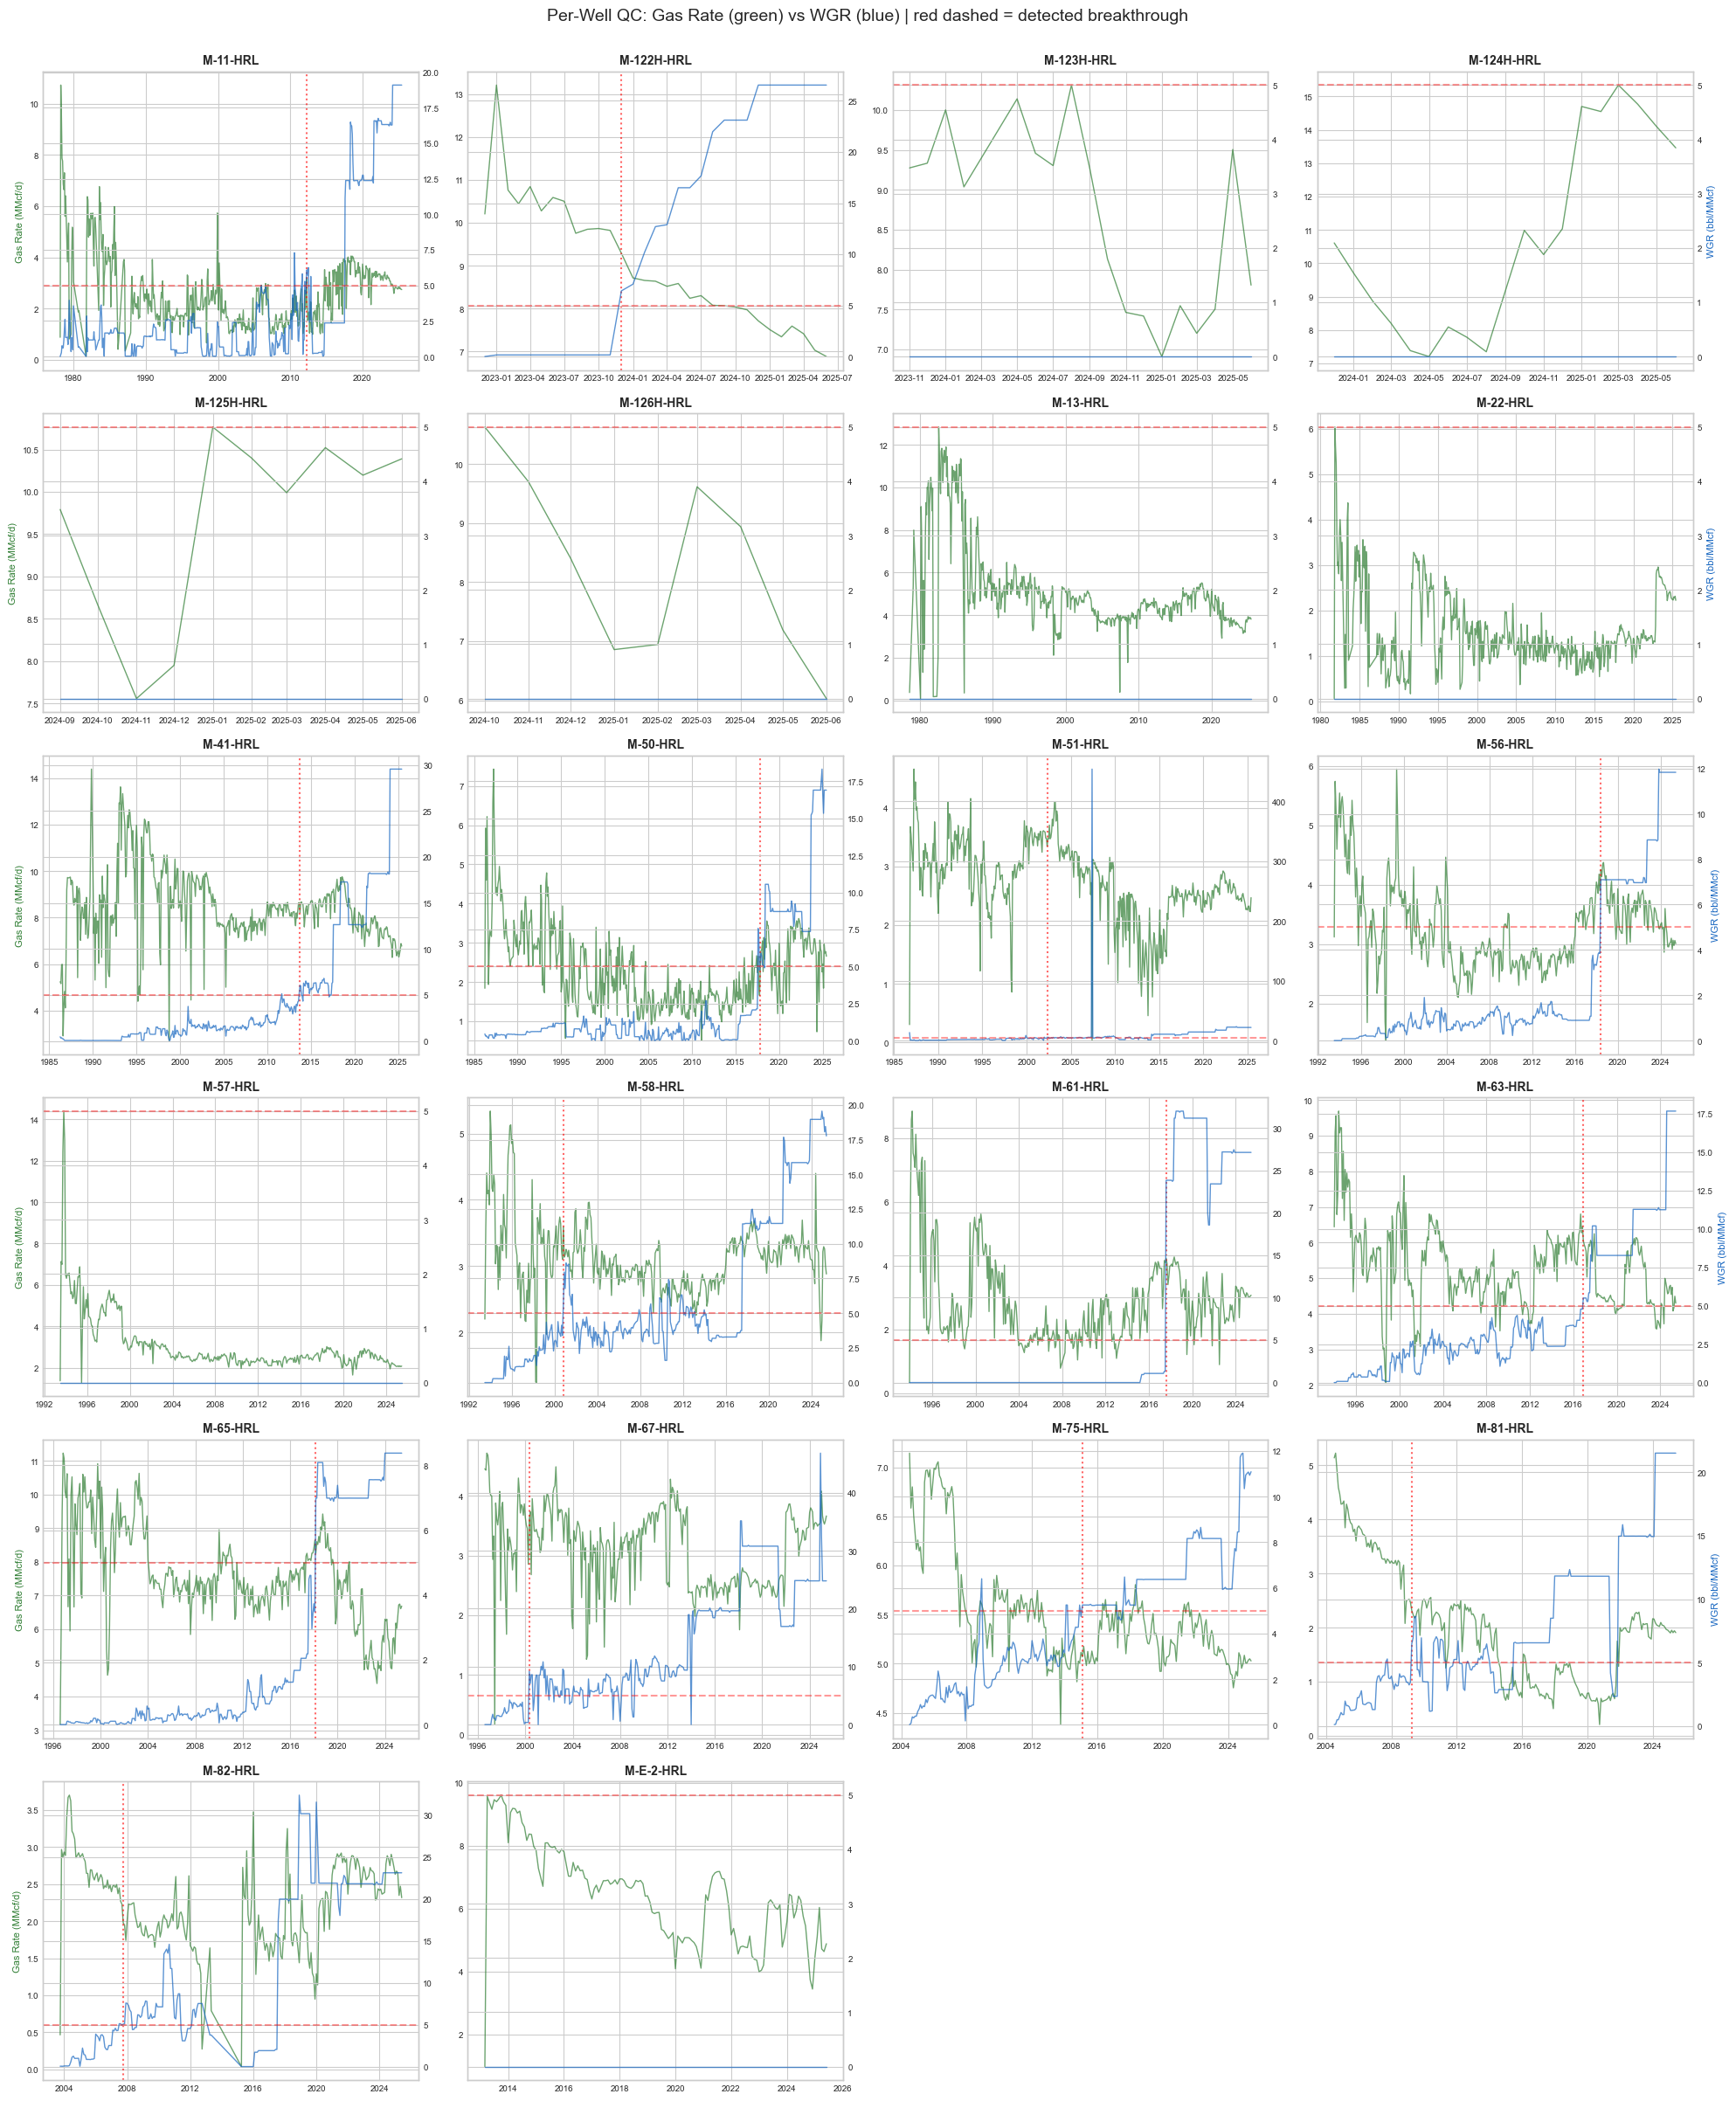

In [33]:
# --- 6.1 Per-well QC plots: Gas Rate, WGR, WHFP overlaid ---
wells_sorted = sorted(panel['well'].unique())
n_wells = len(wells_sorted)
ncols = 4
nrows = int(np.ceil(n_wells / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4*nrows), squeeze=False)

for idx, well in enumerate(wells_sorted):
    ax = axes[idx//ncols, idx%ncols]
    wd = panel[panel['well']==well].sort_values('date')
    wd = wd[wd['gas_mmcf'] > 0]
    if len(wd) == 0:
        ax.set_visible(False); continue

    ax.plot(wd['date'], wd['gas_rate_mmcfd'], color='#2E7D32', alpha=0.7,
            linewidth=1, label='Gas Rate (MMcf/d)')
    ax2 = ax.twinx()
    ax2.plot(wd['date'], wd['wgr'], color='#1565C0', alpha=0.7,
             linewidth=1, label=f'WGR')
    ax2.axhline(y=WGR_THRESHOLD, color='red', linestyle='--', alpha=0.4,
                label=f'WGR={WGR_THRESHOLD}')

    # Mark detected breakthrough date if any
    if well in bt_results and bt_results[well]['event_observed'] == 1:
        bt_date = bt_results[well]['breakthrough_date']
        if bt_date is not None:
            ax.axvline(x=bt_date, color='red', linestyle=':', alpha=0.6, linewidth=1.5)

    ax.set_title(well, fontsize=10, fontweight='bold')
    ax.tick_params(labelsize=7)
    ax2.tick_params(labelsize=7)
    if idx % ncols == 0:
        ax.set_ylabel('Gas Rate (MMcf/d)', fontsize=8, color='#2E7D32')
    if idx % ncols == ncols-1:
        ax2.set_ylabel('WGR (bbl/MMcf)', fontsize=8, color='#1565C0')

for idx in range(n_wells, nrows*ncols):
    axes[idx//ncols, idx%ncols].set_visible(False)

plt.suptitle('Per-Well QC: Gas Rate (green) vs WGR (blue) | red dashed = detected breakthrough',
             fontsize=14, y=1.001)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_per_well_qc.png', dpi=150, bbox_inches='tight')
plt.show()

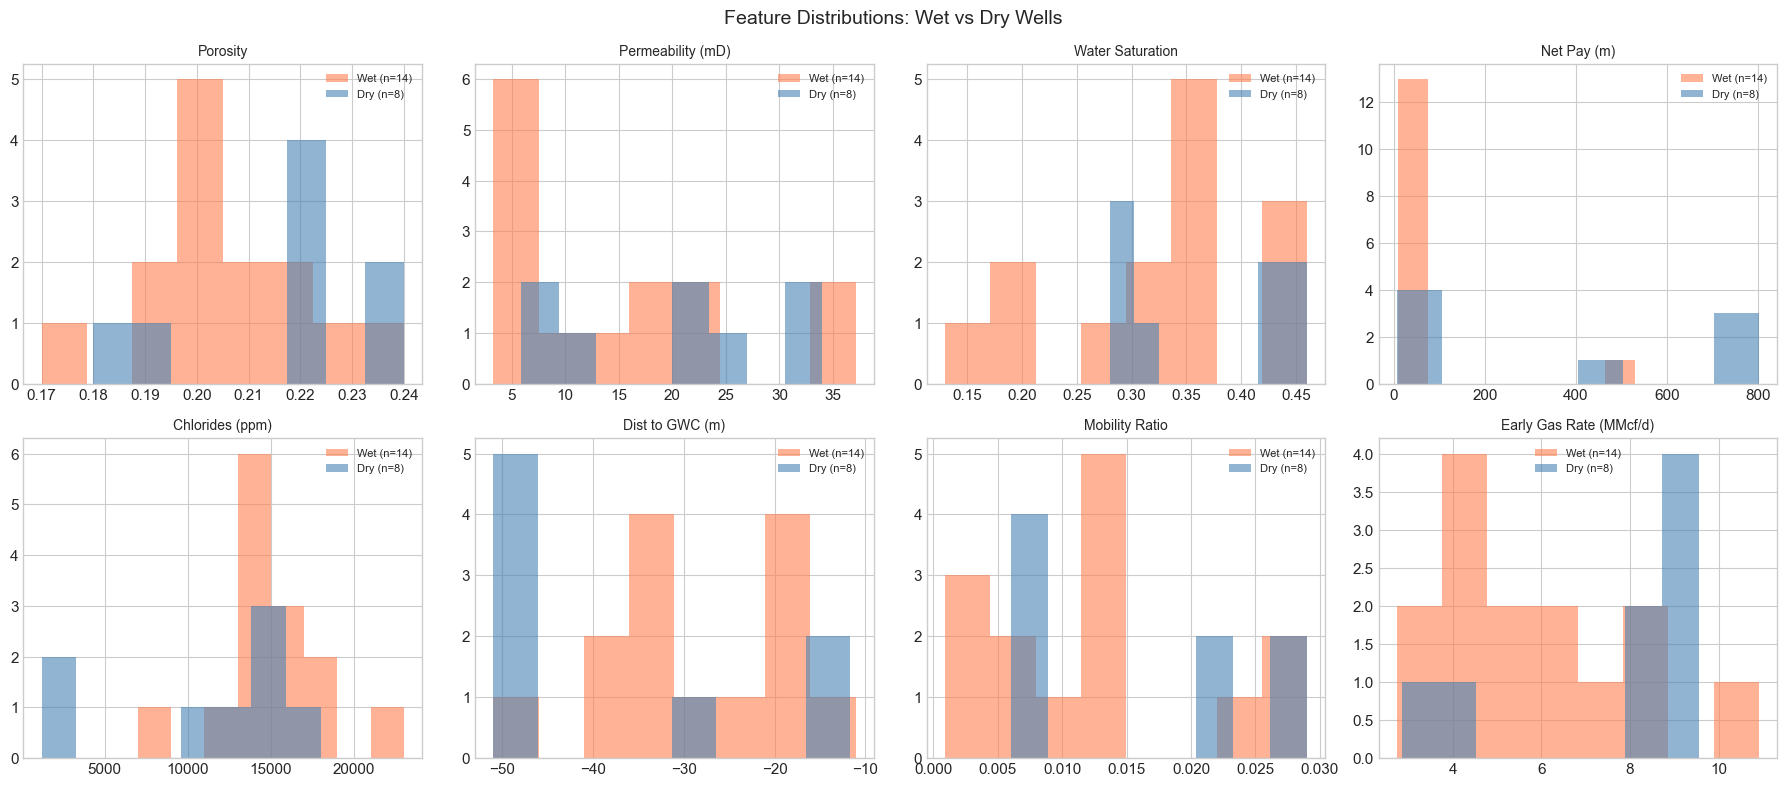

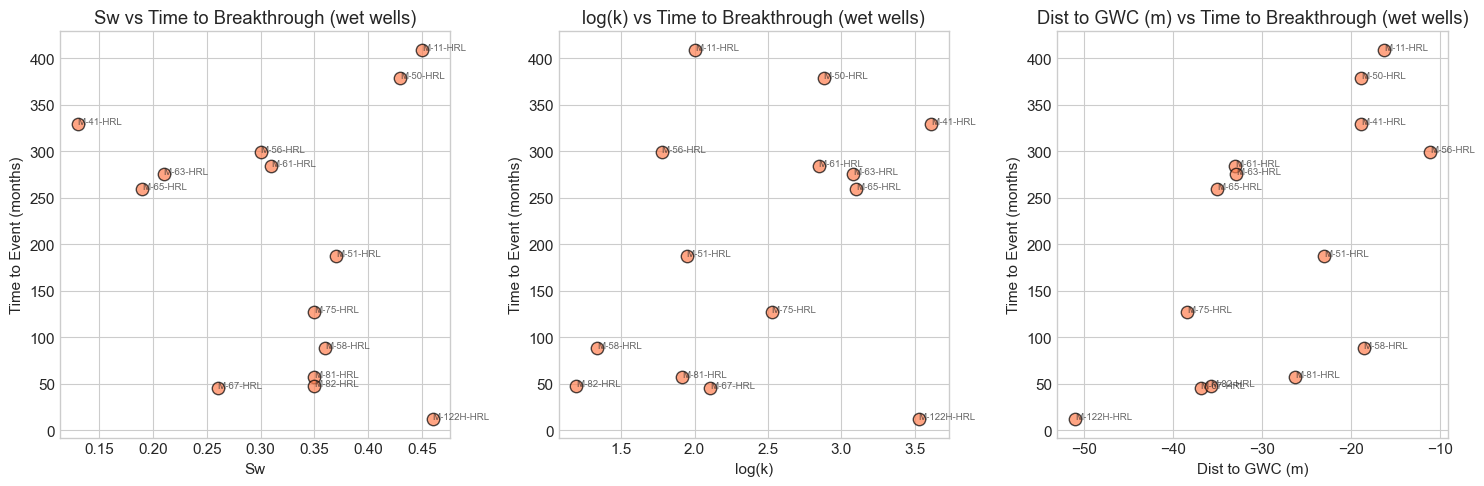

In [27]:
# --- 6.2 Static property distributions: wet vs dry ---
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
props = ['porosity','permeability_md','sw','net_pay_m',
         'chlorides_ppm','dist_to_gwc_m','mobility_ratio','early_gas_rate']
titles = ['Porosity','Permeability (mD)','Water Saturation','Net Pay (m)',
          'Chlorides (ppm)','Dist to GWC (m)','Mobility Ratio','Early Gas Rate (MMcf/d)']

for i, (prop, title) in enumerate(zip(props, titles)):
    ax = axes[i//4, i%4]
    if prop in survival.columns:
        wet = survival[survival['event_observed']==1][prop].dropna()
        dry = survival[survival['event_observed']==0][prop].dropna()
        if len(wet) > 0:
            ax.hist(wet, alpha=0.6, color='coral', label=f'Wet (n={len(wet)})', bins=8)
        if len(dry) > 0:
            ax.hist(dry, alpha=0.6, color='steelblue', label=f'Dry (n={len(dry)})', bins=8)
        ax.set_title(title, fontsize=10)
        ax.legend(fontsize=8)

plt.suptitle('Feature Distributions: Wet vs Dry Wells', fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Time-to-event vs key features for wet wells (additional diagnostic)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
wet = survival[survival['event_observed']==1]
for ax, feat, label in zip(axes, ['sw','log_perm','dist_to_gwc_m'],
                           ['Sw','log(k)','Dist to GWC (m)']):
    ax.scatter(wet[feat], wet['time_to_event_months'],
               s=80, alpha=0.7, color='coral', edgecolor='black')
    for _, r in wet.iterrows():
        ax.annotate(str(r['well']), (r[feat], r['time_to_event_months']),
                    fontsize=7, alpha=0.7)
    ax.set_xlabel(label); ax.set_ylabel('Time to Event (months)')
    ax.set_title(f'{label} vs Time to Breakthrough (wet wells)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02b_feature_vs_tte.png', dpi=150, bbox_inches='tight')
plt.show()

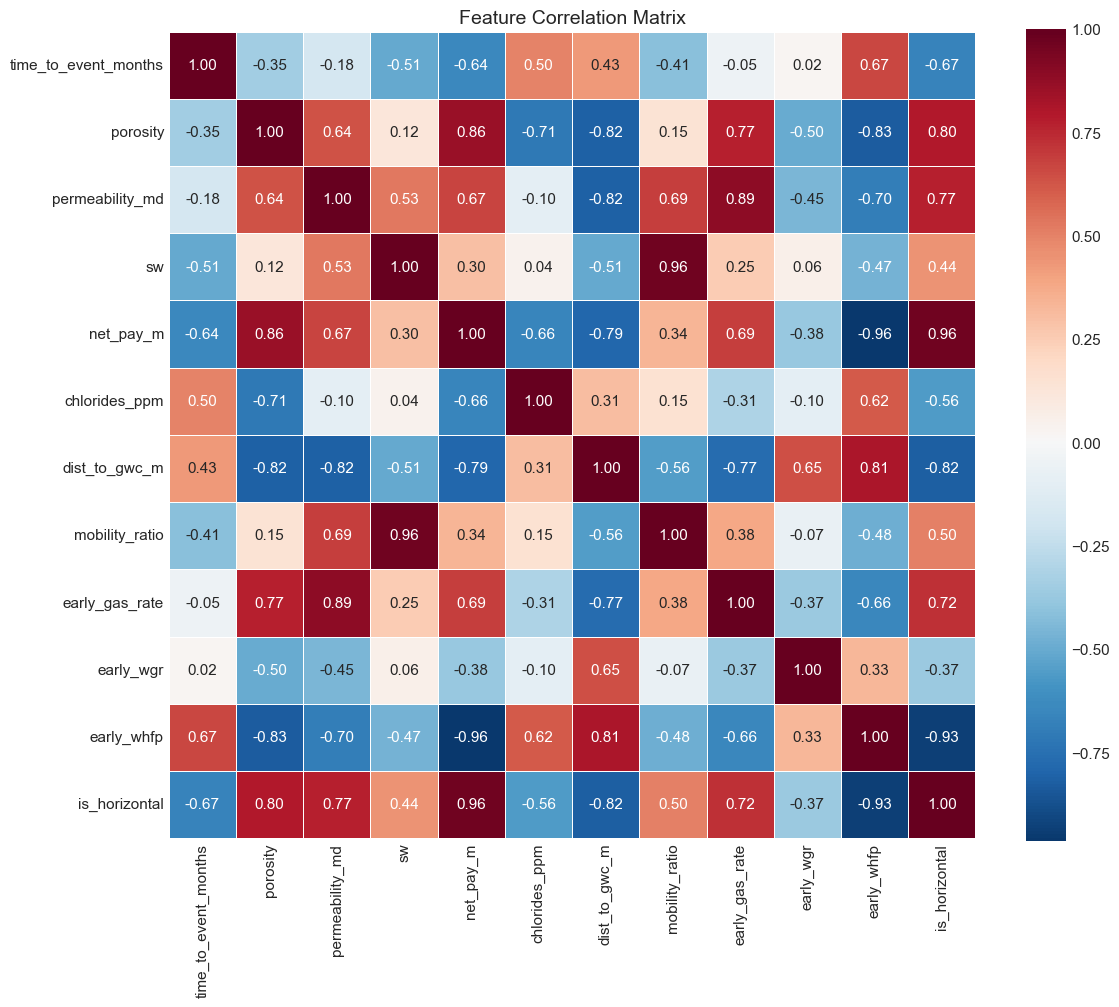

In [28]:
# --- 6.3 Correlation matrix of survival features ---
corr_cols = ['time_to_event_months','porosity','permeability_md','sw','net_pay_m',
             'chlorides_ppm','dist_to_gwc_m','mobility_ratio','early_gas_rate',
             'early_wgr','early_whfp','is_horizontal']
corr_data = survival[corr_cols].dropna()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_data.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, square=True, linewidths=0.5)
ax.set_title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Kaplan-Meier Analysis

Non-parametric survival baseline. Sets the bar that any model must beat. Stratified plots reveal which features actually carry signal.

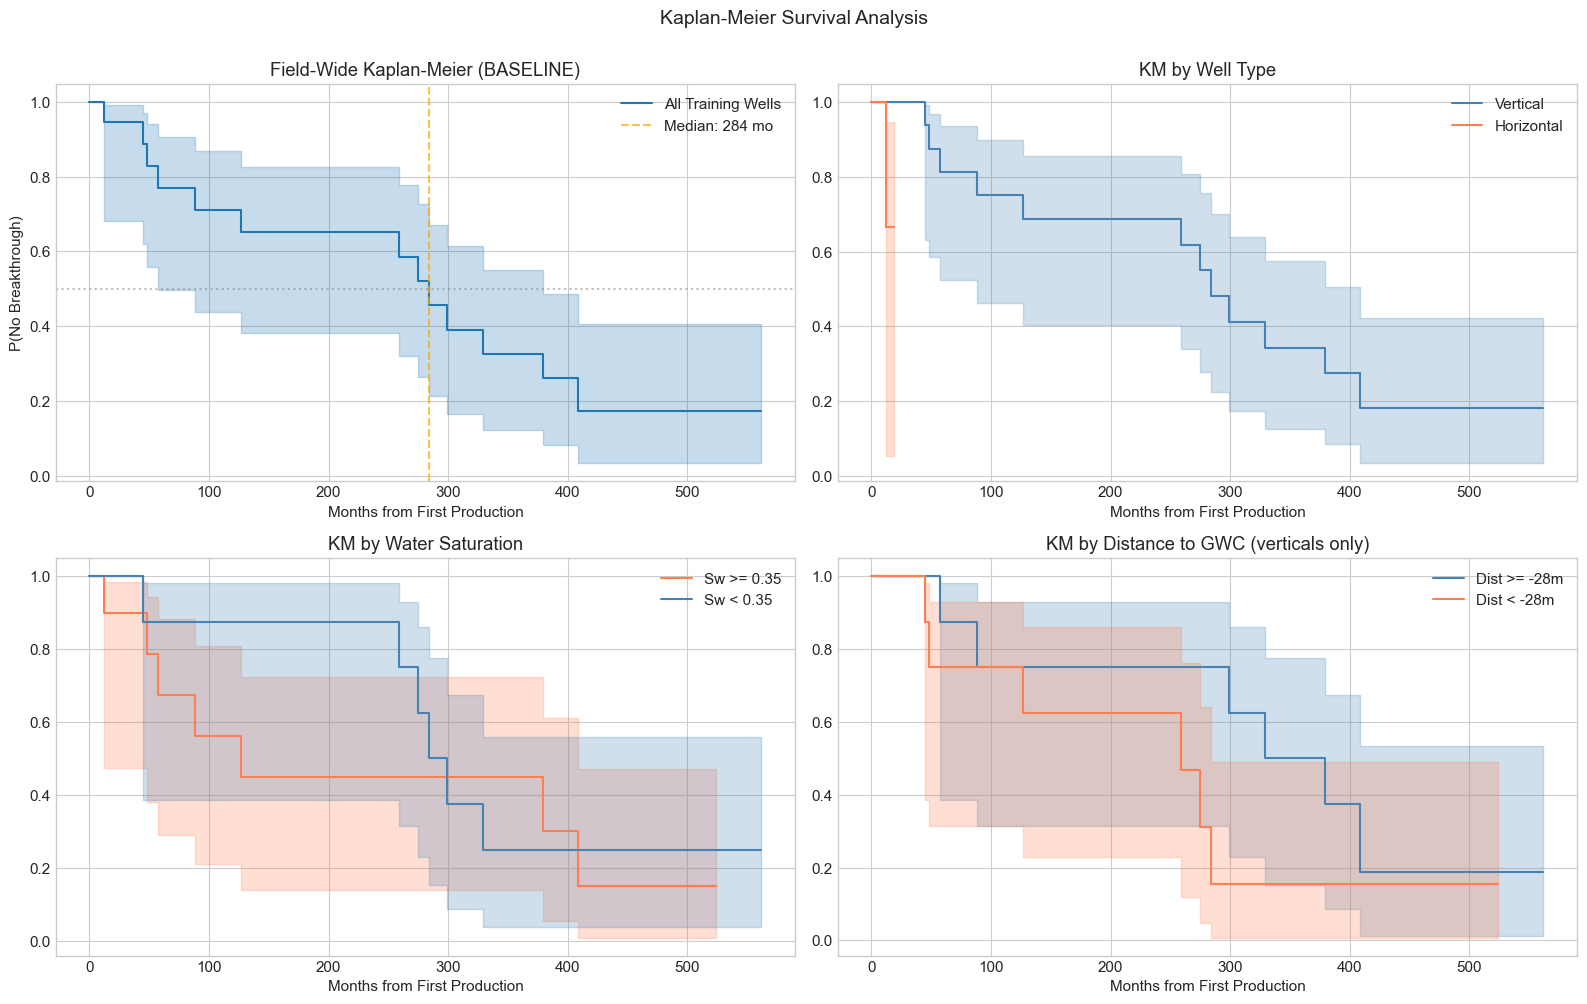


Field-wide KM median survival: 284.0 months
This is the BASELINE the model must beat per-well.


In [34]:
# --- 7.1 Kaplan-Meier: field-wide and stratified ---
kmf = KaplanMeierFitter()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Overall KM
ax = axes[0,0]
kmf.fit(train_df['time_to_event_months'], event_observed=train_df['event_observed'],
        label='All Training Wells')
kmf.plot_survival_function(ax=ax, ci_show=True)
km_median = kmf.median_survival_time_
ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5)
if not np.isinf(km_median):
    ax.axvline(x=km_median, color='orange', linestyle='--', alpha=0.7,
               label=f'Median: {km_median:.0f} mo')
ax.set_title('Field-Wide Kaplan-Meier (BASELINE)')
ax.set_xlabel('Months from First Production'); ax.set_ylabel('P(No Breakthrough)')
ax.legend()

# By well type
ax = axes[0,1]
for wtype, label, color in [(0,'Vertical','steelblue'),(1,'Horizontal','coral')]:
    mask = train_df['is_horizontal']==wtype
    if mask.sum() > 0:
        kmf.fit(train_df.loc[mask,'time_to_event_months'],
                event_observed=train_df.loc[mask,'event_observed'], label=label)
        kmf.plot_survival_function(ax=ax, color=color, ci_show=True)
ax.set_title('KM by Well Type')
ax.set_xlabel('Months from First Production'); ax.legend()

# By Sw (median split)
ax = axes[1,0]
sw_median = train_df['sw'].median()
for grp, lbl, c in [('high',f'Sw >= {sw_median:.2f}','coral'),
                    ('low', f'Sw < {sw_median:.2f}', 'steelblue')]:
    mask = train_df['sw'] >= sw_median if grp=='high' else train_df['sw'] < sw_median
    if mask.sum() > 0:
        kmf.fit(train_df.loc[mask,'time_to_event_months'],
                event_observed=train_df.loc[mask,'event_observed'], label=lbl)
        kmf.plot_survival_function(ax=ax, color=c, ci_show=True)
ax.set_title('KM by Water Saturation')
ax.set_xlabel('Months from First Production'); ax.legend()

# By distance to GWC (verticals only - horizontals are at constant assumed depth)
ax = axes[1,1]
vert_only = train_df[train_df['is_horizontal']==0]
if len(vert_only) > 1:
    dgwc_median = vert_only['dist_to_gwc_m'].median()
    for grp, lbl, c in [('far', f'Dist >= {dgwc_median:.0f}m', 'steelblue'),
                        ('near',f'Dist < {dgwc_median:.0f}m', 'coral')]:
        mask = (vert_only['dist_to_gwc_m'] >= dgwc_median) if grp=='far' else (vert_only['dist_to_gwc_m'] < dgwc_median)
        if mask.sum() > 0:
            kmf.fit(vert_only.loc[mask,'time_to_event_months'],
                    event_observed=vert_only.loc[mask,'event_observed'], label=lbl)
            kmf.plot_survival_function(ax=ax, color=c, ci_show=True)
    ax.set_title('KM by Distance to GWC (verticals only)')
    ax.set_xlabel('Months from First Production'); ax.legend()

plt.suptitle('Kaplan-Meier Survival Analysis', fontsize=14, y=1.001)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_kaplan_meier.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nField-wide KM median survival: {km_median:.1f} months')
print('This is the BASELINE the model must beat per-well.')

In [ ]:
# --- 7.2 Log-rank tests ---
print('=== LOG-RANK TESTS ===\n')

vert  = train_df[train_df['is_horizontal']==0]
horiz = train_df[train_df['is_horizontal']==1]
if len(vert) > 0 and len(horiz) > 0:
    lr = logrank_test(vert['time_to_event_months'], horiz['time_to_event_months'],
                      event_observed_A=vert['event_observed'],
                      event_observed_B=horiz['event_observed'])
    print(f'Vertical vs Horizontal:  p={lr.p_value:.4f} '
          f'({"significant" if lr.p_value<0.05 else "not significant at alpha=0.05"})')

high_sw = train_df[train_df['sw'] >= sw_median]
low_sw  = train_df[train_df['sw'] <  sw_median]
if len(high_sw) > 0 and len(low_sw) > 0:
    lr = logrank_test(low_sw['time_to_event_months'], high_sw['time_to_event_months'],
                      event_observed_A=low_sw['event_observed'],
                      event_observed_B=high_sw['event_observed'])
    print(f'Low-Sw vs High-Sw:       p={lr.p_value:.4f} '
          f'({"significant" if lr.p_value<0.05 else "not significant at alpha=0.05"})')

vert_only = train_df[train_df['is_horizontal']==0]
if len(vert_only) > 1:
    dgwc_med = vert_only['dist_to_gwc_m'].median()
    far  = vert_only[vert_only['dist_to_gwc_m'] >= dgwc_med]
    near = vert_only[vert_only['dist_to_gwc_m'] <  dgwc_med]
    if len(far) > 0 and len(near) > 0:
        lr = logrank_test(near['time_to_event_months'], far['time_to_event_months'],
                          event_observed_A=near['event_observed'],
                          event_observed_B=far['event_observed'])
        print(f'Near-GWC vs Far-GWC:     p={lr.p_value:.4f} '
              f'({"significant" if lr.p_value<0.05 else "not significant at alpha=0.05"})')

print('\nNote: with 13 events the log-rank test has limited power.')
print('Even non-significant separations can be informative for model design.')

---
## 8. Cox Proportional Hazards Model

Primary interpretable baseline. **Reduced to 4 features** (dropped `porosity` - correlated with permeability and adds little independent signal in carbonates).

Physics-motivated feature set:
1. `sw` - water saturation (higher -> faster breakthrough)
2. `log_perm` - log permeability (higher -> faster coning)
3. `dist_to_gwc_m` - distance to GWC (closer -> faster)
4. `log_gas_rate` - early gas rate (higher drawdown -> faster coning)

EPV = 13 events / 4 features = 3.25 (below the standard EPV=10 rule, so L2 regularisation is doing real work).

In [35]:
# --- 8.1 Prepare Cox PH data ---
cox_features = ['sw','log_perm','dist_to_gwc_m','log_gas_rate']

cox_data = train_df[['well','time_to_event_months','event_observed'] + cox_features].copy()
cox_data = cox_data.dropna(subset=cox_features)

print(f'Cox PH training data: {len(cox_data)} wells')
print(f'Events: {int(cox_data["event_observed"].sum())} / {len(cox_data)}')
print(f'EPV: {cox_data["event_observed"].sum() / len(cox_features):.2f}')
print()
print(cox_data[['well'] + cox_features].describe())

Cox PH training data: 21 wells
Events: 13 / 21
EPV: 3.25

              sw   log_perm  dist_to_gwc_m  log_gas_rate
count  21.000000  21.000000      21.000000     21.000000
mean    0.338095   2.596059     -32.401095      1.802211
std     0.094054   0.755036      14.498113      0.419859
min     0.130000   1.193922     -51.000000      1.008123
25%     0.300000   2.001480     -48.748110      1.483319
50%     0.350000   2.844909     -33.000000      1.878179
75%     0.420000   3.113515     -18.850000      2.165712
max     0.460000   3.613617     -11.100000      2.389006


In [36]:
# --- 8.2 Fit Cox PH ---
cph = CoxPHFitter(penalizer=0.1)
cph.fit(cox_data[['time_to_event_months','event_observed'] + cox_features],
        duration_col='time_to_event_months', event_col='event_observed')

print('=== COX PH RESULTS ===')
cph.print_summary()
print(f'\nConcordance Index: {cph.concordance_index_:.3f}')

=== COX PH RESULTS ===


<lifelines.CoxPHFitter: fitted with 21 total observations, 8 right-censored observations>
             duration col = 'time_to_event_months'
                event col = 'event_observed'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 21
number of events observed = 13
   partial log-likelihood = -26.86
         time fit was run = 2026-04-15 11:04:49 UTC

---
               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                      
sw            -2.91      0.05      3.23           -9.25            3.43                0.00               30.87
log_perm      -0.29      0.75      0.50           -1.27            0.68                0.28                1.98
dist_to_gwc_m -0.05      0.95      0.03           -0.10           -0.00                0.90                1.00
log_gas_rate   0.18      1.19      0.75           -1.30            1.65                0.27                5.21

               cmp to     z    p  -log2(p)
covariate                                 
sw               0.00 -0.90 0.37      1.44
log_perm         0.00 -0.58 0.56      0.84
dist_to_gwc_m    0.00 -2.00 0.05      4.45
log_gas_rate     0.00  0.23 0.81      0.30
---
Concordance = 0.76
Partial AIC = 61.72
log-likelihood ratio test = 4.56 on 4 df
-log2(p) of ll-ratio test = 1.58


Concordance Index: 0.758


In [37]:
# --- 8.3 Physics sign check (Cox PH) ---
print('=== PHYSICS SIGN CHECK (Cox PH) ===')
print('In Cox PH: hazard ratio HR > 1 means HIGHER hazard (faster breakthrough)\n')

expected_signs = {
    'sw'           : 'positive',  # higher Sw -> faster
    'log_perm'     : 'positive',  # higher perm -> faster coning
    'dist_to_gwc_m': 'negative',  # further from GWC -> slower
    'log_gas_rate' : 'positive',  # higher rate -> faster
}

hazard_ratios = np.exp(cph.params_)
physics_ok = True
for feat, expected in expected_signs.items():
    if feat in cph.params_.index:
        coef   = cph.params_[feat]
        hr     = hazard_ratios[feat]
        actual = 'positive' if coef > 0 else 'negative'
        match  = (actual == expected)
        if not match: physics_ok = False
        status = 'OK' if match else 'WRONG SIGN'
        print(f'  {feat:18s}: coef={coef:+.3f}, HR={hr:.3f}, '
              f'expected={expected:9s}, actual={actual:9s} -> {status}')

if physics_ok:
    print('\nAll hazard ratio signs match coning physics.')
else:
    print('\nWARNING: Some signs are wrong. Section 11 will refit with constraints.')

=== PHYSICS SIGN CHECK (Cox PH) ===
In Cox PH: hazard ratio HR > 1 means HIGHER hazard (faster breakthrough)

  sw                : coef=-2.908, HR=0.055, expected=positive , actual=negative  -> WRONG SIGN
  log_perm          : coef=-0.291, HR=0.748, expected=positive , actual=negative  -> WRONG SIGN
  dist_to_gwc_m     : coef=-0.053, HR=0.949, expected=negative , actual=negative  -> OK
  log_gas_rate      : coef=+0.176, HR=1.193, expected=positive , actual=positive  -> OK



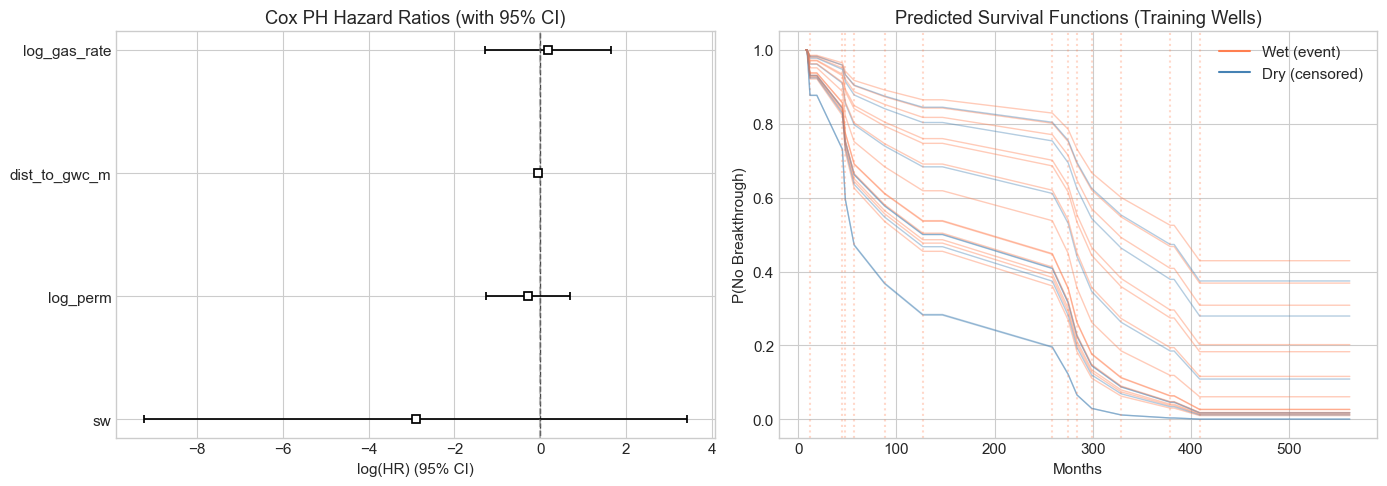

In [38]:
# --- 8.4 Cox PH visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
cph.plot(ax=ax)
ax.set_title('Cox PH Hazard Ratios (with 95% CI)')
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)

ax = axes[1]
for _, row in cox_data.iterrows():
    sf = cph.predict_survival_function(row[cox_features].to_frame().T)
    color = 'coral' if row['event_observed']==1 else 'steelblue'
    ax.plot(sf.index, sf.values.flatten(), color=color, alpha=0.4, linewidth=1)
    if row['event_observed'] == 1:
        ax.axvline(x=row['time_to_event_months'], color=color,
                   linestyle=':', alpha=0.3)
ax.set_title('Predicted Survival Functions (Training Wells)')
ax.set_xlabel('Months'); ax.set_ylabel('P(No Breakthrough)')
from matplotlib.lines import Line2D
ax.legend(handles=[Line2D([0],[0], color='coral', label='Wet (event)'),
                   Line2D([0],[0], color='steelblue', label='Dry (censored)')])

plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_cox_ph_results.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Weibull AFT Model

Parametric model that directly yields P10/P50/P90 time-to-event predictions per well.

In [39]:
# --- 9.1 Fit Weibull AFT ---
aft_features = cox_features  # Same 4 features

aft_data = train_df[['well','time_to_event_months','event_observed'] + aft_features].copy()
aft_data = aft_data.dropna(subset=aft_features)

waft = WeibullAFTFitter(penalizer=0.01)
waft.fit(aft_data[['time_to_event_months','event_observed'] + aft_features],
         duration_col='time_to_event_months', event_col='event_observed')

print('=== WEIBULL AFT RESULTS ===')
waft.print_summary()
print(f'\nAIC: {waft.AIC_:.2f}')
print(f'BIC: {waft.BIC_:.2f}')
print(f'Concordance Index: {waft.concordance_index_:.3f}')

=== WEIBULL AFT RESULTS ===


<lifelines.WeibullAFTFitter: fitted with 21 total observations, 8 right-censored observations>
             duration col = 'time_to_event_months'
                event col = 'event_observed'
                penalizer = 0.01
   number of observations = 21
number of events observed = 13
           log-likelihood = -85.57
         time fit was run = 2026-04-15 11:05:25 UTC

---
                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                      
lambda_ dist_to_gwc_m  0.05      1.05      0.02            0.01            0.10                1.01                1.10
        log_gas_rate  -0.09      0.91      0.69           -1.45            1.26                0.24                3.53
        log_perm       0.53      1.69      0.52           -0.49            1.54                0.61                4.67
        sw             2.80     16.39      2.98           -3.05            8.65                0.05             5687.35
        Intercept      5.07    159.70      1.86            1.42            8.72                4.15             6146.42
rho_    Intercept      0.31      1.36      0.22           -0.12            0.73                0.89                2.08

                       cmp to     z    p  -log2(p)
param   covariate                                 
lambda_ dist_to_gwc_m    0.00  2.24 0.02      5.33
        log_gas_rate     0.00 -0.13 0.89      0.16
        log_perm         0.00  1.01 0.31      1.69
        sw               0.00  0.94 0.35      1.52
        Intercept        0.00  2.72 0.01      7.28
rho_    Intercept        0.00  1.43 0.15      2.70
---
Concordance = 0.76
AIC = 183.14
log-likelihood ratio test = 5.27 on 4 df
-log2(p) of ll-ratio test = 1.94


AIC: 183.14
BIC: 177.23
Concordance Index: 0.758


In [40]:
# --- 9.2 Compare AFT distributions ---
print('=== AFT MODEL COMPARISON ===\n')
models_to_try = [
    ('Weibull AFT',     WeibullAFTFitter(penalizer=0.01)),
    ('LogNormal AFT',   LogNormalAFTFitter(penalizer=0.01)),
    ('LogLogistic AFT', LogLogisticAFTFitter(penalizer=0.01)),
]

aft_comparison = []
fit_cols = ['time_to_event_months','event_observed'] + aft_features
for name, model in models_to_try:
    try:
        model.fit(aft_data[fit_cols], duration_col='time_to_event_months',
                  event_col='event_observed')
        aft_comparison.append({'Model':name,'AIC':model.AIC_,'BIC':model.BIC_,
                               'C-Index':model.concordance_index_})
    except Exception as e:
        print(f'{name}: FAILED - {e}')

comp_df = pd.DataFrame(aft_comparison).sort_values('AIC')
print(comp_df.to_string(index=False))
print(f'\nBest model by AIC: {comp_df.iloc[0]["Model"]}')

=== AFT MODEL COMPARISON ===

          Model        AIC        BIC  C-Index
LogLogistic AFT 181.172428 175.261473 0.750000
  LogNormal AFT 181.761489 175.850534 0.741935
    Weibull AFT 183.141741 177.230786 0.758065

Best model by AIC: LogLogistic AFT


In [44]:
# --- 9.3 Weibull AFT physics sign check ---
print('=== PHYSICS SIGN CHECK (Weibull AFT) ===')
print('Positive coef = LONGER time to event (protective)\n')

expected_signs_aft = {
    'sw'           : 'negative',
    'log_perm'     : 'negative',
    'dist_to_gwc_m': 'positive',
    'log_gas_rate' : 'negative',
}

def get_aft_mu_params(model):
    """Robust extraction of mu_ (location) parameters across lifelines versions."""
    p = model.params_
    if isinstance(p.index, pd.MultiIndex):
        # MultiIndex: levels are ('mu_', feature) or ('rho_', feature)
        if 'mu_' in p.index.get_level_values(0):
            return p.xs('mu_', level=0)
        # Some versions use 'lambda_' for Weibull
        if 'lambda_' in p.index.get_level_values(0):
            return p.xs('lambda_', level=0)
        # Fallback: take first level
        first_level = p.index.get_level_values(0)[0]
        return p.xs(first_level, level=0)
    else:
        # Flat index — already just feature names (drop intercept-like rows)
        return p.drop(['Intercept', '_intercept', 'rho_'], errors='ignore')

mu_params = get_aft_mu_params(waft)

aft_physics_ok = True
for feat, expected in expected_signs_aft.items():
    if feat not in mu_params.index:
        print(f'  {feat:18s}: not in model')
        continue
    coef   = mu_params[feat]
    actual = 'positive' if coef > 0 else 'negative'
    match  = actual == expected
    if not match: aft_physics_ok = False
    status = 'OK' if match else 'WRONG SIGN'
    print(f'  {feat:18s}: coef={coef:+.4f}, expected={expected:9s}, '
          f'actual={actual:9s} -> {status}')

if aft_physics_ok:
    print('\nAll AFT coefficient signs match coning physics.')
else:
    print('\nWARNING: Will attempt physics-constrained fit in Section 11.')

=== PHYSICS SIGN CHECK (Weibull AFT) ===
Positive coef = LONGER time to event (protective)

  sw                : coef=+2.7969, expected=negative , actual=positive  -> WRONG SIGN
  log_perm          : coef=+0.5251, expected=negative , actual=positive  -> WRONG SIGN
  dist_to_gwc_m     : coef=+0.0513, expected=positive , actual=positive  -> OK
  log_gas_rate      : coef=-0.0927, expected=negative , actual=negative  -> OK



---
## 10. Random Survival Forest

Non-parametric benchmark. **Aggressive regularisation** because N=17 with 13 events: trees can memorise the training set otherwise.

RSF C-index (in-sample): 0.847  (optimistic)
RSF C-index (OOB):       0.419  (honest)

events, trees overfit and there is no signal left for held-out wells.
Cox PH and Weibull AFT remain the primary models. RSF is for comparison only.

Feature Importances (permutation, mean +/- std):
  dist_to_gwc_m       : +0.2758 +/- 0.0416
  log_perm            : +0.0637 +/- 0.0175
  sw                  : +0.0629 +/- 0.0255
  log_gas_rate        : +0.0306 +/- 0.0216


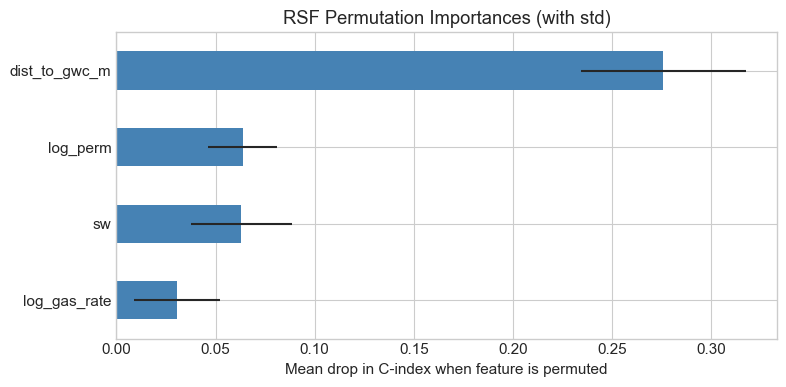

In [46]:
if HAS_SKSURV:
    from sksurv.metrics import concordance_index_censored
    from sklearn.inspection import permutation_importance

    rsf_data = train_df[cox_features + ['time_to_event_months','event_observed']].dropna()
    X_rsf = rsf_data[cox_features].values
    y_rsf = Surv.from_arrays(event=rsf_data['event_observed'].astype(bool),
                             time=rsf_data['time_to_event_months'])

    rsf = RandomSurvivalForest(
        n_estimators=300,
        min_samples_split=5,
        min_samples_leaf=3,
        max_depth=3,
        max_features='sqrt',
        oob_score=True,
        random_state=42,
        n_jobs=-1,
    )
    rsf.fit(X_rsf, y_rsf)

    rsf_cindex_in   = rsf.score(X_rsf, y_rsf)
    rsf_cindex_oob  = rsf.oob_score_
    print(f'RSF C-index (in-sample): {rsf_cindex_in:.3f}  (optimistic)')
    print(f'RSF C-index (OOB):       {rsf_cindex_oob:.3f}  (honest)')

    if rsf_cindex_oob < 0.55:
        print('\nWARNING: RSF OOB C-index is at or below random (0.5). With N=17 and 13')
        print('events, trees overfit and there is no signal left for held-out wells.')
        print('Cox PH and Weibull AFT remain the primary models. RSF is for comparison only.\n')

    # Permutation importance (works for any sksurv model)
    try:
        perm_imp = permutation_importance(
            rsf, X_rsf, y_rsf,
            n_repeats=10, random_state=42, n_jobs=-1
        )
        importances = pd.Series(perm_imp.importances_mean, index=cox_features)
        importances_std = pd.Series(perm_imp.importances_std, index=cox_features)

        print('Feature Importances (permutation, mean +/- std):')
        for f in importances.sort_values(ascending=False).index:
            print(f'  {f:20s}: {importances[f]:+.4f} +/- {importances_std[f]:.4f}')

        fig, ax = plt.subplots(figsize=(8, 4))
        importances.sort_values().plot(
            kind='barh', ax=ax, color='steelblue',
            xerr=importances_std.reindex(importances.sort_values().index)
        )
        ax.set_title('RSF Permutation Importances (with std)')
        ax.set_xlabel('Mean drop in C-index when feature is permuted')
        ax.axvline(x=0, color='black', linewidth=0.5)
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / '06_rsf_importance.png', dpi=150, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f'Permutation importance failed: {e}')
        importances = None

    rsf_cindex = rsf_cindex_oob
else:
    print('scikit-survival not available. Skipping RSF.')
    rsf = None
    rsf_cindex = None

---
## 11. Physics-Constrained Model

Iteratively increase L2 penalty until all signs match coning physics, **with a C-index floor of 0.65**: a model that has correct signs but useless predictive power is not acceptable. If the penalty sweep fails, fall back to a reduced 3-feature set.

In [47]:
# --- 11.1 Physics-constrained Weibull AFT ---
# Strategy: increase L2 penalty iteratively. Accept the first penalty that gives
# correct signs AND C-index >= 0.65. Otherwise drop features and retry.

CINDEX_FLOOR = 0.65

def signs_correct(model, expected, fit_features):
    mu_params = get_aft_mu_params(model)
    for feat, exp in expected.items():
        if feat not in fit_features or feat not in mu_params.index:
            continue
        coef = mu_params[feat]
        actual = 'positive' if coef > 0 else 'negative'
        if actual != exp:
            return False
    return True

best_constrained_model = None
best_penalty           = None
best_features          = None

for penalty in [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]:
    try:
        model = WeibullAFTFitter(penalizer=penalty)
        model.fit(aft_data[['time_to_event_months','event_observed'] + aft_features],
                  duration_col='time_to_event_months', event_col='event_observed')
        ok = signs_correct(model, expected_signs_aft, aft_features)
        ci = model.concordance_index_
        marker = 'PASS' if (ok and ci >= CINDEX_FLOOR) else ('signs OK but C-low' if ok else 'wrong signs')
        print(f'penalty={penalty:5.2f}  C-index={ci:.3f}  signs_ok={ok}  -> {marker}')
        if ok and ci >= CINDEX_FLOOR:
            best_constrained_model = model
            best_penalty  = penalty
            best_features = aft_features
            break
    except Exception as e:
        print(f'penalty={penalty}: FAILED - {e}')

if best_constrained_model is None:
    print('\nFull feature set could not satisfy constraints. Trying reduced 3-feature set...\n')
    reduced_features = ['sw','dist_to_gwc_m','log_gas_rate']
    reduced_signs = {k:v for k,v in expected_signs_aft.items() if k in reduced_features}
    
    for penalty in [0.01, 0.1, 0.5, 1.0, 2.0]:
        rd = aft_data[['time_to_event_months','event_observed'] + reduced_features].dropna()
        try:
            model = WeibullAFTFitter(penalizer=penalty)
            model.fit(rd, duration_col='time_to_event_months', event_col='event_observed')
            ok = signs_correct(model, reduced_signs, reduced_features)
            ci = model.concordance_index_
            print(f'reduced penalty={penalty:5.2f}  C={ci:.3f}  signs_ok={ok}')
            if ok and ci >= CINDEX_FLOOR:
                best_constrained_model = model
                best_penalty  = penalty
                best_features = reduced_features
                print(f'  ACCEPTED reduced model with {reduced_features}')
                break
        except Exception as e:
            print(f'reduced penalty={penalty}: FAILED - {e}')

if best_constrained_model is None:
    print('\nNo physics-consistent model meeting C-index floor. Falling back to vanilla Weibull.')
    best_constrained_model = waft
    best_penalty  = 0.01
    best_features = aft_features
else:
    print(f'\nFinal physics-constrained model:')
    print(f'  Features: {best_features}')
    print(f'  Penalizer: {best_penalty}')
    print(f'  C-index: {best_constrained_model.concordance_index_:.3f}')

penalty= 0.01  C-index=0.758  signs_ok=False  -> wrong signs
penalty= 0.05  C-index=0.766  signs_ok=False  -> wrong signs
penalty= 0.10  C-index=0.782  signs_ok=False  -> wrong signs
penalty= 0.50  C-index=0.782  signs_ok=False  -> wrong signs
penalty= 1.00  C-index=0.726  signs_ok=False  -> wrong signs
penalty= 2.00  C-index=0.702  signs_ok=False  -> wrong signs
penalty= 5.00  C-index=0.702  signs_ok=False  -> wrong signs

Full feature set could not satisfy constraints. Trying reduced 3-feature set...

reduced penalty= 0.01  C=0.790  signs_ok=False
reduced penalty= 0.10  C=0.758  signs_ok=False
reduced penalty= 0.50  C=0.742  signs_ok=False
reduced penalty= 1.00  C=0.702  signs_ok=False
reduced penalty= 2.00  C=0.702  signs_ok=False

No physics-consistent model meeting C-index floor. Falling back to vanilla Weibull.


---
## 12. P10/P50/P90 Forecasts for Target Wells

The headline deliverable: P10/P50/P90 breakthrough timing for M-123H, M-124H, M-125H, M-126H. M-122H is included as a validation anchor.

`predict_percentiles` now uses **linear interpolation** to find exact P10/P50/P90 from the survival curve (the previous nearest-neighbour approach could be off by 1-2 months for shallow curves).

In [48]:
def predict_percentiles(model, features_df, feature_cols):
    """
    Extract P10/P50/P90 from a fitted AFT model's survival function via linear interp.
    P90 = 90% probability that breakthrough occurs AFTER this time (conservative)
    P50 = median
    P10 = 10% probability that breakthrough takes longer (optimistic)
    """
    results = []
    for idx, row in features_df.iterrows():
        X = row[feature_cols].to_frame().T
        try:
            sf = model.predict_survival_function(X)
            times = sf.index.values.astype(float)
            probs = sf.values.flatten()
            # Survival probs decrease with time. For np.interp(prob, x, y),
            # x must be increasing -> reverse both arrays.
            probs_rev = probs[::-1]
            times_rev = times[::-1]
            
            p90 = float(np.interp(0.90, probs_rev, times_rev))
            p50 = float(np.interp(0.50, probs_rev, times_rev))
            p10 = float(np.interp(0.10, probs_rev, times_rev))
            
            # Floor + ordering
            p90 = max(0.5, p90)
            p50 = max(p90 + 0.5, p50)
            p10 = max(p50 + 0.5, p10)

            results.append({
                'well'           : row.get('well', idx),
                'P90_months'     : round(p90, 1),
                'P50_months'     : round(p50, 1),
                'P10_months'     : round(p10, 1),
                'survival_times' : times,
                'survival_probs' : probs,
            })
        except Exception as e:
            print(f'Prediction failed for {row.get("well", idx)}: {e}')
            results.append({'well':row.get('well',idx),
                            'P90_months':np.nan,'P50_months':np.nan,'P10_months':np.nan})
    return pd.DataFrame(results)

# Use the best available physics-constrained model
final_model    = best_constrained_model
final_features = best_features
print(f'Using model: {type(final_model).__name__}')
print(f'Features: {final_features}')
print(f'Penalty: {best_penalty}')
print(f'C-index: {final_model.concordance_index_:.3f}')

Using model: WeibullAFTFitter
Features: ['sw', 'log_perm', 'dist_to_gwc_m', 'log_gas_rate']
Penalty: 0.01
C-index: 0.758


In [49]:
# --- 12.1 In-sample prediction for M-122H (proper LOO is in section 14) ---
m122_wells = [w for w in survival['well'].values if str(w).strip().endswith('122H') or str(w).strip()=='122H']
m122_df = survival[survival['well'].isin(m122_wells)].copy()

if len(m122_df) > 0:
    m122_pred = predict_percentiles(final_model, m122_df, final_features)
    actual_bt = m122_df['time_to_event_months'].values[0]

    print('=== M-122H IN-SAMPLE CHECK ===')
    print('(NOTE: M-122H is in training set, so this is in-sample.')
    print(' Honest leave-one-out validation is in Section 14.)\n')
    print(f'Actual breakthrough: {actual_bt:.1f} months')
    print(f'P90 (conservative):  {m122_pred["P90_months"].values[0]} months')
    print(f'P50 (most likely):   {m122_pred["P50_months"].values[0]} months')
    print(f'P10 (optimistic):    {m122_pred["P10_months"].values[0]} months')

    p90 = m122_pred['P90_months'].values[0]
    p10 = m122_pred['P10_months'].values[0]
    if p90 <= actual_bt <= p10:
        print('\nActual is within P90-P10 range (in-sample).')
    else:
        print('\nWARNING: Actual is OUTSIDE P90-P10 range.')
else:
    print('M-122H not found in survival data')

M-122H not found in survival data


In [50]:
# --- 12.2 P10/P50/P90 forecasts for M-123H/124H/125H/126H ---
if len(forecast_df) > 0:
    forecasts = predict_percentiles(final_model, forecast_df, final_features)

    print('=== P10/P50/P90 FORECASTS ===')
    print('Time-to-water-breakthrough from first production (months)\n')
    print(forecasts[['well','P90_months','P50_months','P10_months']].to_string(index=False))

    print(f'\nField-wide KM median baseline: {km_median:.1f} months')
    for _, r in forecasts.iterrows():
        diff = r['P50_months'] - km_median
        direction = 'earlier' if diff < 0 else 'later'
        print(f"  {r['well']:12s} P50={r['P50_months']:6.1f} mo  "
              f"({abs(diff):.1f} mo {direction} than KM baseline)")
else:
    print('No forecast wells found.')

No forecast wells found.


NameError: name 'forecasts' is not defined

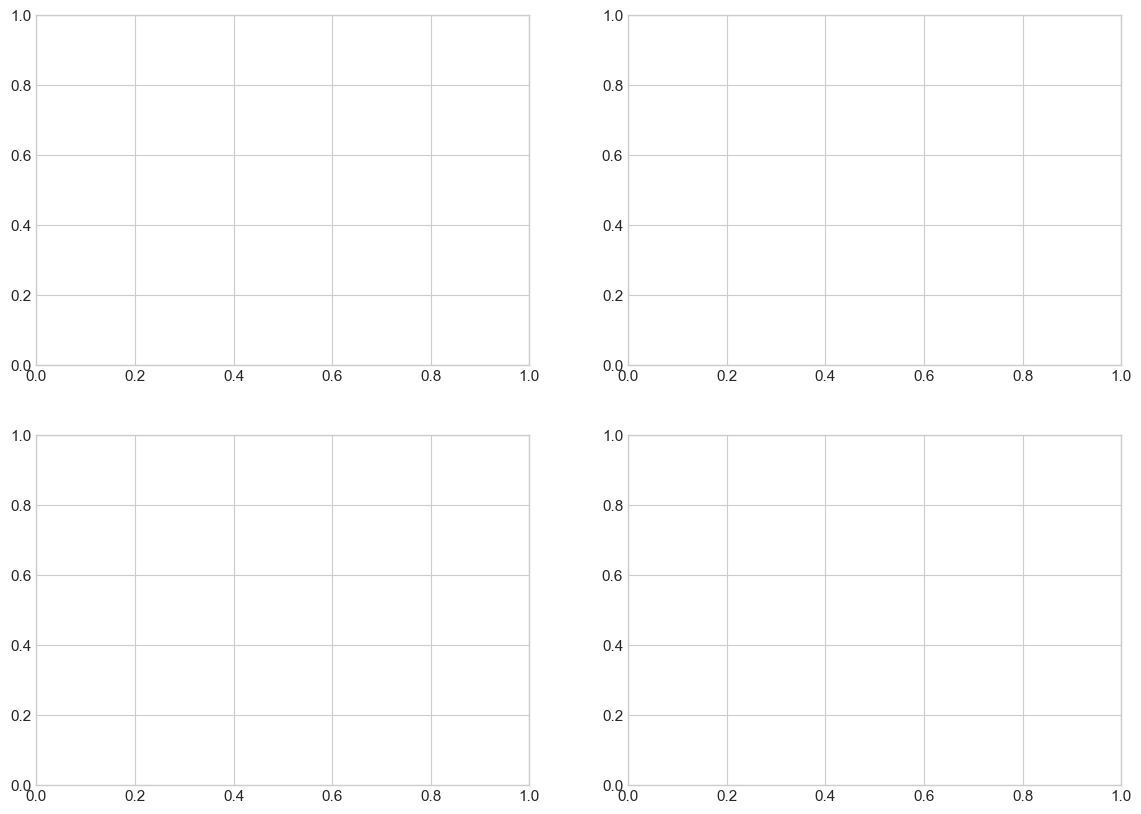

In [51]:
# --- 12.3 Forecast survival curves with current-age reference ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Map well -> current age in months
forecast_age = {r['well']: r['production_months'] for _, r in forecast_df.iterrows()}

for idx, (_, row) in enumerate(forecasts.iterrows()):
    if idx >= 4: break
    ax = axes[idx//2, idx%2]
    well_name = row['well']

    if 'survival_times' in row and row['survival_times'] is not None:
        ax.plot(row['survival_times'], row['survival_probs'],
                color='#e8734a', linewidth=2, label='Predicted S(t)')
        ax.fill_between(row['survival_times'], row['survival_probs'],
                        alpha=0.1, color='#e8734a')

    # P90/P50/P10 markers
    for pval, prob, color, label in [
        (row['P90_months'], 0.9, '#4a9f6e', 'P90'),
        (row['P50_months'], 0.5, '#e8734a', 'P50'),
        (row['P10_months'], 0.1, '#d64545', 'P10'),
    ]:
        ax.axvline(x=pval, color=color, linestyle='--', alpha=0.7)
        ax.plot(pval, prob, 'o', color=color, markersize=8)
        ax.annotate(f'{label}: {pval:.0f} mo', xy=(pval, prob),
                    xytext=(5, 10), textcoords='offset points', fontsize=9, color=color)

    # Current age line - everything to the LEFT of this line should already have happened
    cur_age = forecast_age.get(well_name, 0)
    if cur_age > 0:
        ax.axvline(x=cur_age, color='black', linestyle='-', alpha=0.4, linewidth=1.5,
                   label=f'Current age: {cur_age:.0f} mo')

    # KM baseline
    if not np.isinf(km_median):
        ax.axvline(x=km_median, color='gray', linestyle=':', alpha=0.5,
                   label=f'KM baseline: {km_median:.0f} mo')

    ax.set_title(well_name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Months from First Production')
    ax.set_ylabel('P(No Breakthrough)')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8, loc='lower left')

plt.suptitle('Forecast Survival Curves - Target Wells', fontsize=14, y=1.001)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '07_forecast_survival_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 13. Sensitivity Analysis

P50 vs WGR event threshold. Threshold floor capped at 2 (threshold=1 with min_consecutive=3 collapses too many wells to month-zero events).

In [52]:
# --- 13.1 Sensitivity to WGR threshold ---
wgr_thresholds = [2, 5, 10, 20]   # capped at 2 (threshold=1 is too noisy)
sensitivity_results = []

for thresh in wgr_thresholds:
    bt_sens = {}
    for w in panel['well'].unique():
        r = detect_breakthrough_wgr(panel[panel['well']==w], threshold=thresh)
        if r is not None: bt_sens[w] = r
    bt_sens_df = pd.DataFrame(bt_sens).T.reset_index().rename(columns={'index':'well'})

    surv_sens = bt_sens_df.merge(
        sub[['well','porosity','permeability_md','sw','net_pay_m','perf_midpoint_md']],
        on='well', how='left'
    )
    surv_sens['log_perm'] = np.log(surv_sens['permeability_md'].clip(lower=0.1))
    surv_sens['is_horizontal'] = surv_sens['well'].isin(HORIZONTAL_WELLS).astype(int)
    surv_sens['dist_to_gwc_m'] = np.where(
        surv_sens['is_horizontal']==1,
        GWC_TVD - HORIZONTAL_TVD_PROXY,
        GWC_TVD - surv_sens['perf_midpoint_md']
    )
    surv_sens['log_gas_rate'] = np.log(surv_sens['early_gas_rate'].clip(lower=0.001))

    excl = exclude_wells
    fcst = forecast_wells
    train_sens = surv_sens[~surv_sens['well'].isin(excl + fcst)].copy()
    fcst_sens  = surv_sens[surv_sens['well'].isin(fcst)].copy()

    try:
        m = WeibullAFTFitter(penalizer=best_penalty or 0.1)
        fd = train_sens[['time_to_event_months','event_observed'] + final_features].dropna()
        m.fit(fd, duration_col='time_to_event_months', event_col='event_observed')
        if len(fcst_sens) > 0:
            preds = predict_percentiles(m, fcst_sens, final_features)
            for _, r in preds.iterrows():
                sensitivity_results.append({'WGR_Threshold':thresh,'Well':r['well'],
                                            'P50_months':r['P50_months']})
    except Exception as e:
        print(f'Threshold {thresh}: {e}')

if sensitivity_results:
    sens_df = pd.DataFrame(sensitivity_results)
    sens_pivot = sens_df.pivot(index='Well', columns='WGR_Threshold', values='P50_months')
    print('=== P50 SENSITIVITY TO WGR THRESHOLD ===')
    print(sens_pivot.round(1).to_string())

    fig, ax = plt.subplots(figsize=(10, 5))
    sens_pivot.T.plot(marker='o', ax=ax)
    ax.set_xlabel('WGR Threshold (bbl/MMcf)'); ax.set_ylabel('Predicted P50 (months)')
    ax.set_title('P50 Forecast Sensitivity to Event-Definition Threshold')
    ax.legend(title='Well', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '08_sensitivity.png', dpi=150, bbox_inches='tight')
    plt.show()

TypeError: loop of ufunc does not support argument 0 of type numpy.float64 which has no callable log method

---
## 14. Leave-One-Out Validation (Honest C-Index)

The headline accuracy number for the Mari status update. Each well is held out one at a time, the model is refit on the remaining 16 wells, and predictions are compared to actuals. **The held-out M-122H prediction is the credibility test for the horizontal regime.**

=== LEAVE-ONE-OUT RESULTS (13 events) ===

      well  actual_months  pred_p90  pred_p50  pred_p10  abs_error  within_p90_p10
  M-11-HRL          409.0     148.9     562.0     562.5      153.0            True
M-122H-HRL           12.0     164.4     523.4     562.0      511.4           False
  M-41-HRL          329.0     156.6     562.0     562.5      233.0            True
  M-50-HRL          379.0     302.8     562.0     562.5      183.0            True
  M-56-HRL          299.0      97.5     408.6     562.0      109.6            True
  M-58-HRL           88.0      77.9     301.5     562.0      213.5            True
  M-61-HRL          284.0      45.9     200.5     499.6       83.5            True
  M-63-HRL          275.0      36.6     158.5     391.6      116.5            True
  M-65-HRL          258.9      28.4     120.1     295.8      138.8            True
  M-67-HRL           45.0      36.0     140.2     328.1       95.2            True
  M-75-HRL          127.0      35.2     150.

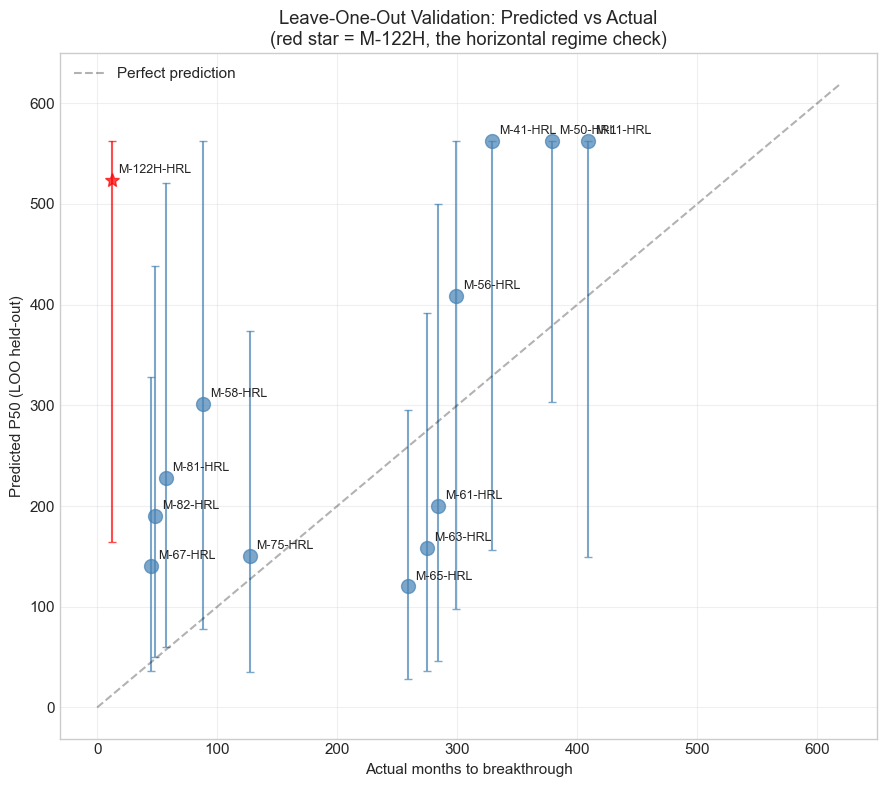

In [53]:
# --- 14.1 Leave-one-out predictions across the training set ---
loo_preds = []
for idx in train_df.index:
    train_loo = train_df.drop(idx)
    test_loo  = train_df.loc[[idx]]
    fit_data  = train_loo[['time_to_event_months','event_observed'] + final_features].dropna()
    if len(fit_data) < 3 or fit_data['event_observed'].sum() < 2:
        continue
    try:
        m = WeibullAFTFitter(penalizer=best_penalty or 0.1)
        m.fit(fit_data, duration_col='time_to_event_months', event_col='event_observed')
        pred = predict_percentiles(m, test_loo, final_features)
        loo_preds.append({
            'well'         : test_loo['well'].values[0],
            'event'        : int(test_loo['event_observed'].values[0]),
            'actual_months': float(test_loo['time_to_event_months'].values[0]),
            'pred_p50'     : pred['P50_months'].values[0],
            'pred_p10'     : pred['P10_months'].values[0],
            'pred_p90'     : pred['P90_months'].values[0],
            'is_horizontal': int(test_loo['is_horizontal'].values[0]),
        })
    except Exception as e:
        print(f'LOO failed for {test_loo["well"].values[0]}: {e}')

loo_df = pd.DataFrame(loo_preds)
events_only = loo_df[loo_df['event']==1].copy()
events_only['abs_error'] = (events_only['pred_p50'] - events_only['actual_months']).abs()
events_only['within_p90_p10'] = ((events_only['pred_p90'] <= events_only['actual_months']) &
                                  (events_only['actual_months'] <= events_only['pred_p10']))

print(f'=== LEAVE-ONE-OUT RESULTS ({len(events_only)} events) ===\n')
print(events_only[['well','actual_months','pred_p90','pred_p50','pred_p10',
                   'abs_error','within_p90_p10']].to_string(index=False))

print(f'\nMedian absolute error (P50 vs actual): {events_only["abs_error"].median():.1f} months')
print(f'Mean absolute error  (P50 vs actual): {events_only["abs_error"].mean():.1f} months')
print(f'Coverage of P90-P10 interval: '
      f'{events_only["within_p90_p10"].mean()*100:.0f}% (target: 80%)')

# Highlight M-122H
m122_loo = events_only[events_only['well'].str.contains('122H', na=False)]
if len(m122_loo) > 0:
    r = m122_loo.iloc[0]
    print(f'\n=== M-122H HORIZONTAL VALIDATION (LOO, held-out) ===')
    print(f'  Actual: {r["actual_months"]:.0f} months')
    print(f'  Predicted P50: {r["pred_p50"]:.0f} months  (error: {r["abs_error"]:.0f} months)')
    print(f'  P90-P10 range: [{r["pred_p90"]:.0f}, {r["pred_p10"]:.0f}]')
    print(f'  Within P90-P10: {r["within_p90_p10"]}')
    print('\n  This is the headline credibility number for the Mari status update.')

# Plot
fig, ax = plt.subplots(figsize=(9, 8))
for _, r in events_only.iterrows():
    color = 'red' if '122H' in str(r['well']) else 'steelblue'
    marker = '*' if '122H' in str(r['well']) else 'o'
    ms = 200 if marker=='*' else 80
    ax.errorbar(r['actual_months'], r['pred_p50'],
                yerr=[[max(0, r['pred_p50']-r['pred_p90'])],
                      [max(0, r['pred_p10']-r['pred_p50'])]],
                fmt=marker, color=color, capsize=3, markersize=10, alpha=0.7)
    ax.annotate(str(r['well']), (r['actual_months'], r['pred_p50']),
                fontsize=9, xytext=(5,5), textcoords='offset points')

max_v = max(events_only['actual_months'].max(), events_only['pred_p10'].max()) * 1.1
ax.plot([0, max_v], [0, max_v], 'k--', alpha=0.3, label='Perfect prediction')
ax.set_xlabel('Actual months to breakthrough')
ax.set_ylabel('Predicted P50 (LOO held-out)')
ax.set_title('Leave-One-Out Validation: Predicted vs Actual\n(red star = M-122H, the horizontal regime check)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '09_loo_validation.png', dpi=150, bbox_inches='tight')
plt.show()

### 14.2 Extrapolation Check

Plot the 4 forecast wells against the training feature cloud. If a forecast well sits **outside** the training distribution on the most informative features, the model is extrapolating and the P10-P90 interval should be widened (or the prediction flagged as low-confidence).

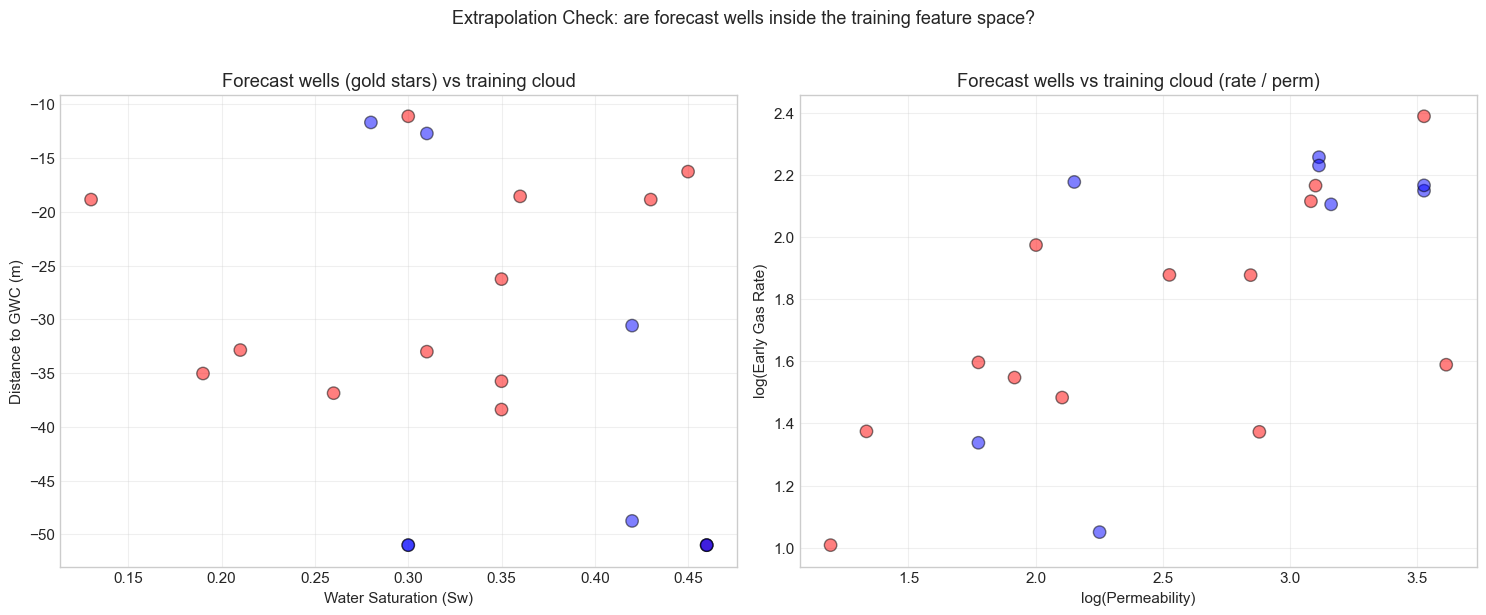

=== EXTRAPOLATION SUMMARY ===



In [54]:
# --- Extrapolation check: forecast wells vs training cloud ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Sw vs dist_to_gwc
ax = axes[0]
colors = ['red' if e==1 else 'blue' for e in train_df['event_observed']]
ax.scatter(train_df['sw'], train_df['dist_to_gwc_m'], s=80, c=colors, alpha=0.5,
           edgecolor='black', label='Training (red=wet, blue=dry)')
for _, r in forecast_df.iterrows():
    ax.scatter(r['sw'], r['dist_to_gwc_m'], s=300, marker='*', color='gold',
               edgecolor='black', linewidth=1.5, zorder=10)
    ax.annotate(str(r['well']), (r['sw'], r['dist_to_gwc_m']),
                fontsize=11, fontweight='bold', xytext=(8, 8),
                textcoords='offset points')
ax.set_xlabel('Water Saturation (Sw)')
ax.set_ylabel('Distance to GWC (m)')
ax.set_title('Forecast wells (gold stars) vs training cloud')
ax.grid(alpha=0.3)

# Plot 2: log_perm vs log_gas_rate
ax = axes[1]
ax.scatter(train_df['log_perm'], train_df['log_gas_rate'], s=80, c=colors, alpha=0.5,
           edgecolor='black')
for _, r in forecast_df.iterrows():
    ax.scatter(r['log_perm'], r['log_gas_rate'], s=300, marker='*', color='gold',
               edgecolor='black', linewidth=1.5, zorder=10)
    ax.annotate(str(r['well']), (r['log_perm'], r['log_gas_rate']),
                fontsize=11, fontweight='bold', xytext=(8, 8),
                textcoords='offset points')
ax.set_xlabel('log(Permeability)')
ax.set_ylabel('log(Early Gas Rate)')
ax.set_title('Forecast wells vs training cloud (rate / perm)')
ax.grid(alpha=0.3)

plt.suptitle('Extrapolation Check: are forecast wells inside the training feature space?',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '10_extrapolation_check.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print('=== EXTRAPOLATION SUMMARY ===\n')
for _, fr in forecast_df.iterrows():
    flags = []
    for feat in ['sw','dist_to_gwc_m','log_perm','log_gas_rate']:
        train_min, train_max = train_df[feat].min(), train_df[feat].max()
        if pd.notna(fr[feat]):
            if fr[feat] < train_min or fr[feat] > train_max:
                flags.append(f'{feat} OUT-OF-RANGE ({fr[feat]:.2f} vs train [{train_min:.2f}, {train_max:.2f}])')
    if flags:
        print(f'{fr["well"]}: {len(flags)} extrapolation flags')
        for f in flags: print(f'    - {f}')
    else:
        print(f'{fr["well"]}: all features within training range')

---
## 15. Model Comparison Summary

In [55]:
# --- Model comparison table ---
print('=== MODEL COMPARISON SUMMARY ===\n')
comparison = []

comparison.append({'Model':'Kaplan-Meier (baseline)','C-Index':'-','AIC':'-',
                   'Physics Signs':'N/A','Notes':f'Median={km_median:.0f} mo'})
comparison.append({'Model':'Cox PH','C-Index':f'{cph.concordance_index_:.3f}',
                   'AIC':f'{cph.AIC_partial_:.1f}' if hasattr(cph,'AIC_partial_') else '-',
                   'Physics Signs':'OK' if physics_ok else 'WRONG','Notes':'Penalizer=0.1'})
comparison.append({'Model':'Weibull AFT','C-Index':f'{waft.concordance_index_:.3f}',
                   'AIC':f'{waft.AIC_:.1f}',
                   'Physics Signs':'OK' if aft_physics_ok else 'WRONG','Notes':'Penalizer=0.01'})
if best_constrained_model is not None and best_constrained_model is not waft:
    comparison.append({'Model':'Physics-Constrained AFT',
                       'C-Index':f'{best_constrained_model.concordance_index_:.3f}',
                       'AIC':f'{best_constrained_model.AIC_:.1f}',
                       'Physics Signs':'OK (forced)',
                       'Notes':f'Penalizer={best_penalty}, features={len(best_features)}'})
if HAS_SKSURV and rsf is not None:
    comparison.append({'Model':'Random Survival Forest',
                       'C-Index':f'{rsf_cindex:.3f}','AIC':'N/A',
                       'Physics Signs':'N/A (black box)',
                       'Notes':'OOB C-index (honest)'})

# LOO summary
if 'events_only' in dir() and len(events_only) > 0:
    comparison.append({
        'Model':'AFT (LOO held-out)',
        'C-Index':'-',
        'AIC':'-',
        'Physics Signs':'N/A',
        'Notes':f'MAE={events_only["abs_error"].median():.0f} mo, coverage={events_only["within_p90_p10"].mean()*100:.0f}%'
    })

comp_summary = pd.DataFrame(comparison)
print(comp_summary.to_string(index=False))

=== MODEL COMPARISON SUMMARY ===

                  Model C-Index   AIC   Physics Signs                    Notes
Kaplan-Meier (baseline)       -     -             N/A            Median=284 mo
                 Cox PH   0.758  61.7           WRONG            Penalizer=0.1
            Weibull AFT   0.758 183.1           WRONG           Penalizer=0.01
 Random Survival Forest   0.419   N/A N/A (black box)     OOB C-index (honest)
     AFT (LOO held-out)       -     -             N/A MAE=142 mo, coverage=77%


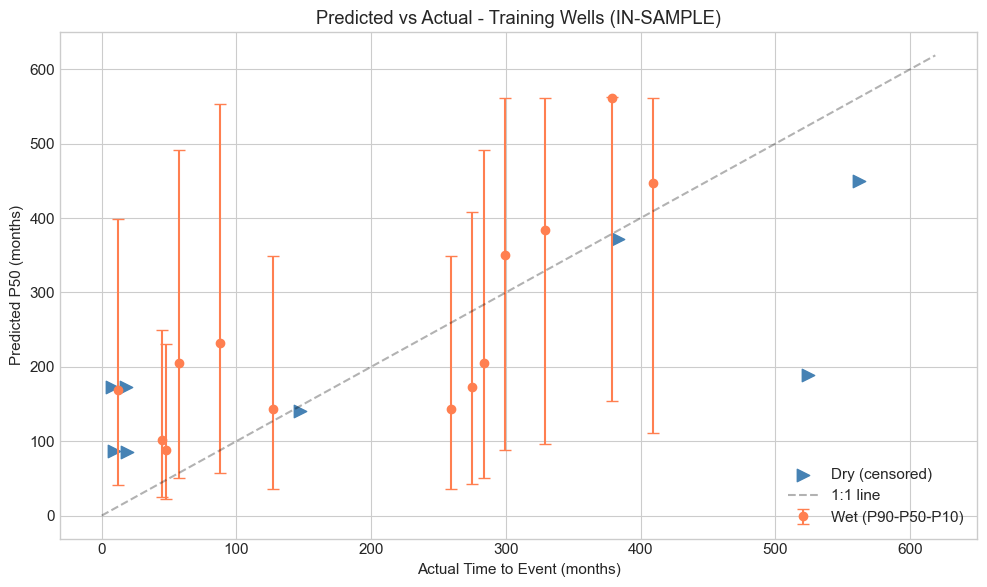

In [56]:
# --- Training well predictions vs actual (in-sample) ---
train_preds = predict_percentiles(final_model, train_df, final_features)

fig, ax = plt.subplots(figsize=(10, 6))
wet = train_df[train_df['event_observed']==1].merge(train_preds, on='well')
dry = train_df[train_df['event_observed']==0].merge(train_preds, on='well')

if len(wet) > 0:
    ax.errorbar(wet['time_to_event_months'], wet['P50_months'],
                yerr=[wet['P50_months'] - wet['P90_months'],
                      wet['P10_months'] - wet['P50_months']],
                fmt='o', color='coral', capsize=4, label='Wet (P90-P50-P10)')
if len(dry) > 0:
    ax.scatter(dry['time_to_event_months'], dry['P50_months'],
               marker='>', color='steelblue', s=80, label='Dry (censored)')

max_val = max(train_df['time_to_event_months'].max(),
              train_preds['P10_months'].max()) * 1.1
ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='1:1 line')
ax.set_xlabel('Actual Time to Event (months)')
ax.set_ylabel('Predicted P50 (months)')
ax.set_title('Predicted vs Actual - Training Wells (IN-SAMPLE)')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / '11_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 16. Model Export

In [57]:
# --- Save model artifacts ---
model_artifacts = {
    'model'         : final_model,
    'model_name'    : f'Physics-Constrained Weibull AFT ({len(final_features)} features)',
    'model_type'    : 'gas_water_breakthrough',
    'features'      : final_features,
    'scaler_params' : {
        'mean': aft_data[final_features].mean().to_dict(),
        'std' : aft_data[final_features].std().to_dict(),
    },
    'regularization': {'type':'L2','penalty':best_penalty if best_penalty else 0.01},
    'metrics'       : {
        'AIC'     : final_model.AIC_,
        'BIC'     : final_model.BIC_,
        'C_Index' : final_model.concordance_index_,
        'LOO_MAE_months': float(events_only['abs_error'].median()) if 'events_only' in dir() and len(events_only)>0 else None,
        'LOO_coverage'  : float(events_only['within_p90_p10'].mean()) if 'events_only' in dir() and len(events_only)>0 else None,
    },
    'event_definition': {
        'metric'                : 'WGR',
        'threshold_bbl_per_mmcf': WGR_THRESHOLD,
        'min_consecutive_months': MIN_CONSECUTIVE_MONTHS,
    },
    'field_info': {
        'name'           : 'Mari Gas Field (HRL)',
        'gwc_tvd'        : GWC_TVD,
        'horizontal_tvd' : HORIZONTAL_TVD_PROXY,
        'formation'      : 'Habib Rahi Limestone',
        'reservoir_type' : 'gas',
    },
    'training_wells'   : train_df['well'].tolist(),
    'excluded_wells'   : exclude_wells,
    'forecast_wells'   : forecast_wells,
    'validation_well'  : validation_well,
    'km_median_months' : float(km_median) if not np.isinf(km_median) else None,
    'forecasts'        : forecasts[['well','P90_months','P50_months','P10_months']].to_dict('records') if len(forecast_df)>0 else [],
    'imputation_log'   : imputation_log,
    'timestamp'        : datetime.now().isoformat(),
}

model_path = Path('mari_water_breakthrough_model.pkl')
with open(model_path, 'wb') as f:
    pickle.dump(model_artifacts, f)

print(f'Model saved to {model_path}')
print(f'Artifact keys: {list(model_artifacts.keys())}')

Model saved to mari_water_breakthrough_model.pkl
Artifact keys: ['model', 'model_name', 'model_type', 'features', 'scaler_params', 'regularization', 'metrics', 'event_definition', 'field_info', 'training_wells', 'excluded_wells', 'forecast_wells', 'validation_well', 'km_median_months', 'forecasts', 'imputation_log', 'timestamp']


---
## 17. Assumptions, Limitations & Challenges

### Assumptions
1. **WGR threshold of 5 bbl/MMcf, sustained 3 months** as breakthrough indicator. Sensitivity tested at 2/5/10/20.
2. **M-51 excluded** from training: water present from first month of true production (Oct 1986); perforations 702-712m MD vs GWC 684m TVD SS suggests perfs in/near water leg, not coning.
3. **WHFP used as pressure proxy** when BHP is missing. Annual BHP available for most wells from 1988+.
4. **MD used as TVD proxy for vertical wells** (TVD = MD - constant RTKB elevation; the offset washes out in the model). For **horizontals**, perforation TVD is overridden with `HORIZONTAL_TVD_PROXY = 735 m` based on M-122H completion sketch (heel ~740m TVD, toe ~742m TVD).
5. **Two-zone model**: Zone A (verticals) and Zone B (horizontals) - based on observation that horizontal perfs (~740m TVD) sit below the reported GWC (684m TVD SS), suggesting they target Habib Rahi Zone-B.
6. **Corey-type relative permeability** (k_rw ~ Sw^2, k_rg ~ (1-Sw)^2) for mobility ratio. Real rel-perm curves would improve this.
7. **Gas viscosity = 0.02 cp, water viscosity = 0.5 cp** at approximate reservoir conditions.
8. **Missing water records = zero water production**.
9. **Monthly granularity** = breakthrough timing resolution +-15 days at best.
10. **Pre-Aug 2015 choke imputed** with per-well median of post-2015 values.

### Limitations
1. **Small sample size**: 13 events in training (after excluding M-51), with EPV = 3.25 for 4 features. L2 regularisation is non-trivial and necessary.
2. **No machine-readable spatial features**: well coordinates exist as DMS in 19 hand-drawn JPG sketches; transcription pending. Distance-to-OWC neighbour features and analog matching are blocked until coordinates are digitised.
3. **Drive mechanism**: pure natural depletion (no waterflood), so injection-pattern features are irrelevant.
4. **Horizontal vs vertical asymmetry**: only 1 horizontal event (M-122H). The horizontal regime is structurally different from verticals (linear inflow vs radial, slotted liner vs cased-hole perforations, much longer net pay), so cross-cohort transfer carries inherent uncertainty.
5. **GWC vs horizontal-perf-depth puzzle**: horizontal perforations appear to sit ~50m below the reported GWC. Best explanation is a deeper sub-zone (Zone B), but Mari should confirm.
6. **Pre-1990 WHFP missing** for 6 oldest wells; partially mitigated by annual BHP from 1988.
7. **MD-only perforations** for horizontals; full MD/TVD survey trajectories not yet provided.
8. **Label noise**: WGR threshold of 5 is a starting point; chloride-confirmed event dates from Mari engineering would tighten the labels.

### Open data items requested from Mari
- Pre-Aug 2015 choke records for the 17 legacy wells
- Remaining Line Pressure records (~62% gap)
- Coordinates as machine-readable CSV (WGS 84)
- Full MD/TVD survey trajectories for the 5 horizontals
- Engineering "first water" date per wet well
- Confirmation of GWC convention vs horizontal perf depths

In [58]:
# --- Final summary ---
print('=' * 60)
print(' MARI WATER BREAKTHROUGH PREDICTION - SUMMARY')
print('=' * 60)
print(f'\nTraining: {len(train_df)} wells ({int(train_df["event_observed"].sum())} events)')
print(f'Excluded: {exclude_wells}')
print(f'Model:    {type(final_model).__name__}')
print(f'Features: {final_features}')
print(f'C-index:  {final_model.concordance_index_:.3f}')
if 'events_only' in dir() and len(events_only) > 0:
    print(f'LOO MAE:  {events_only["abs_error"].median():.1f} months')
    print(f'LOO P90-P10 coverage: {events_only["within_p90_p10"].mean()*100:.0f}%')
print(f'KM baseline median: {km_median:.1f} months')

print(f'\n--- FORECASTS (P10/P50/P90 in months) ---')
if len(forecast_df) > 0:
    for _, r in forecasts.iterrows():
        print(f"  {r['well']:12s} P90={r['P90_months']:6.1f}   P50={r['P50_months']:6.1f}   P10={r['P10_months']:6.1f}")

print(f'\nModel exported to: mari_water_breakthrough_model.pkl')
print('Done.')

 MARI WATER BREAKTHROUGH PREDICTION - SUMMARY

Training: 21 wells (13 events)
Excluded: ['M-51-HRL']
Model:    WeibullAFTFitter
Features: ['sw', 'log_perm', 'dist_to_gwc_m', 'log_gas_rate']
C-index:  0.758
LOO MAE:  142.4 months
LOO P90-P10 coverage: 77%
KM baseline median: 284.0 months

--- FORECASTS (P10/P50/P90 in months) ---

Model exported to: mari_water_breakthrough_model.pkl
Done.
